In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

read in the data

In [2]:
company_data = pd.read_parquet('./case_study_data/company_data.parquet')
company_data

,entity_urn,updated_at,website,ownership_status,headcount,founding_date,twitter_follower_count,linkedin_follower_count,linkedin_url_harmonic,funding_total,...,emp_delta_12m,adj_emp_delta_12m,investor_1,investor_2,investor_3,Prior VC Backed Founder_count,Deep Technical Background_count,Prior Exit_count,Elite Industry Experience_count,emp_highlight_count
0,urn:harmonic:company:3676293,2025-01-06,"{'domain': 'keye.co', 'is_broken': False, 'url...",PRIVATE,15,2021-01-01,22,3228,https://linkedin.com/company/keye,4.250000,...,9.000000,9.000000,1,0,0,1,0,0,2,15
1,urn:harmonic:company:3823516,2025-01-06,"{'domain': 'stack-ai.com', 'is_broken': False,...",PRIVATE,13,2022-12-01,3905,6775,https://linkedin.com/company/stackai,19.079967,...,9.000000,8.910000,2,0,0,3,3,0,0,20
4,urn:harmonic:company:12475768,2025-01-06,"{'domain': 'extend.app', 'is_broken': False, '...",PRIVATE,10,2023-01-01,<NA>,1121,https://linkedin.com/company/extend-app,0.500000,...,4.000000,4.000000,1,0,0,1,0,0,0,13
5,urn:harmonic:company:49899178,2025-01-06,"{'domain': 'hamming.ai', 'is_broken': False, '...",PRIVATE,12,2024-01-01,<NA>,1140,https://linkedin.com/company/hamming-ai,4.300000,...,5.731260,4.871571,1,0,0,2,1,0,0,10
6,urn:harmonic:company:11125538,2025-01-06,"{'domain': 'vooma.com', 'is_broken': False, 'u...",PRIVATE,15,2023-01-01,<NA>,1345,https://linkedin.com/company/vooma-inc,18.324988,...,7.000000,6.750000,3,1,0,3,2,0,2,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15405,urn:harmonic:company:4418743,2025-01-05,"{'domain': 'theleappartners.com', 'is_broken':...",PRIVATE,21,2004-01-01,<NA>,4400,https://linkedin.com/company/the-leap-partners,0.000000,...,6.000000,6.000000,0,0,0,0,0,0,0,2
15436,urn:harmonic:company:4501758,2025-01-03,"{'domain': 'fullcast.com', 'is_broken': False,...",ACQUIRED_OR_MERGED,4,2018-01-01,<NA>,1208,https://linkedin.com/company/datajoin,3.500000,...,-6.000000,-5.100000,0,0,0,0,0,0,0,0
15438,urn:harmonic:company:651225,2025-01-03,"{'domain': 'topquadrant.com', 'is_broken': Fal...",PRIVATE,36,2001-01-01,1795,1460,https://linkedin.com/company/topquadrant,0.000000,...,4.000000,3.400000,0,0,0,0,0,0,2,15
15439,urn:harmonic:company:52637542,2025-01-06,"{'domain': 'getseam.ai', 'is_broken': False, '...",PRIVATE,11,2023-01-01,<NA>,1073,https://linkedin.com/company/seamai,5.000000,...,4.136969,3.516424,1,0,0,2,0,0,2,20


In [3]:
target_company_data = pd.read_parquet('./case_study_data/target_company_data.parquet')
target_company_data

,entity_urn,updated_at,website,ownership_status,headcount,founding_date,twitter_follower_count,linkedin_follower_count,linkedin_url_harmonic,funding_total,...,emp_delta_12m,adj_emp_delta_12m,investor_1,investor_2,investor_3,Prior VC Backed Founder_count,Deep Technical Background_count,Prior Exit_count,Elite Industry Experience_count,emp_highlight_count
0,urn:harmonic:company:1443095,2024-12-18,"{'domain': 'hebbia.ai', 'is_broken': False, 'u...",PRIVATE,15,2020-08-14,617.0,2076,https://linkedin.com/company/hebbia,31.100000,...,8.0,7.896774,3,0,0,7,3,2,4,80
1,urn:harmonic:company:1990249,2024-12-18,"{'domain': 'axionray.com', 'is_broken': False,...",PRIVATE,18,2021-01-01,NaN,739,https://linkedin.com/company/axion-ray,0.421850,...,8.0,6.800000,1,0,0,0,5,0,9,54
2,urn:harmonic:company:3075425,2024-12-18,"{'domain': 'syrup.tech', 'is_broken': False, '...",PRIVATE,17,2020-07-09,NaN,1590,https://linkedin.com/company/syrup-tech,7.300000,...,9.0,7.633333,1,0,0,1,4,0,2,38
3,urn:harmonic:company:10819970,2024-12-18,"{'domain': 'unstructured.io', 'is_broken': Fal...",PRIVATE,11,2022-01-01,22.0,262,https://linkedin.com/company/unstructuredio,0.421850,...,NaN,NaN,3,0,0,1,5,0,4,63
4,urn:harmonic:company:3928206,2024-12-18,"{'domain': 'smarterdx.com', 'is_broken': False...",PRIVATE,7,2020-01-01,NaN,121,https://linkedin.com/company/smarterdx,5.970000,...,NaN,NaN,3,0,0,2,6,1,5,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,urn:harmonic:company:1842794,2024-12-18,"{'domain': 'siro.ai', 'is_broken': False, 'url...",PRIVATE,6,2020-01-01,NaN,358,https://linkedin.com/company/siro-ai,0.421850,...,-1.0,-1.000000,3,0,0,1,0,0,3,44
57,urn:harmonic:company:48201423,2024-12-16,"{'domain': 'browserbase.com', 'is_broken': Fal...",PRIVATE,19,2024-01-01,3728.0,1412,https://linkedin.com/company/browserbasehq,27.500000,...,NaN,NaN,1,0,0,2,0,0,1,21
58,urn:harmonic:company:773593,2024-12-18,"{'domain': 'pomerium.com', 'is_broken': False,...",PRIVATE,14,2019-01-01,200.0,208,https://linkedin.com/company/pomerium-inc,25.300000,...,2.0,1.893333,4,0,0,1,1,0,1,14
59,urn:harmonic:company:1869576,2024-12-18,"{'domain': 'tavus.io', 'is_broken': False, 'ur...",PRIVATE,13,2020-01-01,NaN,926,https://linkedin.com/company/tavus-io,4.140705,...,5.0,4.647059,8,0,0,2,2,0,2,21


### Ensure there are no overlaps between target and non-target data

check if the company data overlaps with the target data

In [4]:
target_in_company_data = company_data[company_data['entity_urn'].isin(target_company_data['entity_urn'])] # 58 rows
target_not_in_company_data = target_company_data[~target_company_data['entity_urn'].isin(company_data['entity_urn'])] # 3 rows

In [5]:
target_in_company_data

,entity_urn,updated_at,website,ownership_status,headcount,founding_date,twitter_follower_count,linkedin_follower_count,linkedin_url_harmonic,funding_total,...,emp_delta_12m,adj_emp_delta_12m,investor_1,investor_2,investor_3,Prior VC Backed Founder_count,Deep Technical Background_count,Prior Exit_count,Elite Industry Experience_count,emp_highlight_count
319,urn:harmonic:company:1704422,2025-01-06,"{'domain': 'prepared911.com', 'is_broken': Fal...",PRIVATE,74,2020-01-01,75,6687,https://linkedin.com/company/prepared911,71.389615,...,61.000000,59.969014,3,0,0,0,1,0,2,51
1382,urn:harmonic:company:1710563,2025-01-06,"{'domain': 'pallet.com', 'is_broken': False, '...",PRIVATE,24,2020-01-01,8079,4040,https://linkedin.com/company/pallet-xyz,8.857279,...,-1.000000,-0.931818,0,0,0,0,0,1,0,9
7805,urn:harmonic:company:1443095,2025-01-03,"{'domain': 'hebbia.ai', 'is_broken': False, 'u...",PRIVATE,103,2020-08-14,4562,23877,https://linkedin.com/company/hebbia,161.100000,...,61.000000,57.576531,3,0,0,8,4,2,3,82
7806,urn:harmonic:company:10894886,2025-01-06,"{'domain': 'tennr.com', 'is_broken': False, 'u...",PRIVATE,69,2021-01-01,<NA>,4866,https://linkedin.com/company/tennrai,60.810000,...,52.000000,50.501695,4,0,0,0,2,0,2,42
7808,urn:harmonic:company:3613480,2025-01-06,"{'domain': 'rogo.ai', 'is_broken': False, 'url...",PRIVATE,42,2021-01-01,731,4522,https://linkedin.com/company/rogoai,30.500000,...,28.000000,27.484211,2,0,0,1,1,0,3,37
7818,urn:harmonic:company:12756714,2025-01-04,"{'domain': 'factory.ai', 'is_broken': False, '...",PRIVATE,62,2023-04-01,5906,4583,https://linkedin.com/company/factory-hq,20.000000,...,16.000000,12.133333,2,0,0,0,3,0,3,46
7820,urn:harmonic:company:21555289,2025-01-06,"{'domain': 'norm.ai', 'is_broken': False, 'url...",PRIVATE,33,2023-01-01,646,3746,https://linkedin.com/company/normative-ai,38.100000,...,22.000000,22.000000,3,0,0,4,2,1,1,38
7830,urn:harmonic:company:4424857,2025-01-06,"{'domain': 'permitflow.com', 'is_broken': Fals...",PRIVATE,74,2022-01-01,199,12468,https://linkedin.com/company/permitflow,37.000000,...,47.000000,45.411268,2,0,0,4,0,0,4,39
7844,urn:harmonic:company:1990249,2025-01-06,"{'domain': 'axionray.com', 'is_broken': False,...",PRIVATE,226,2021-01-01,<NA>,3963,https://linkedin.com/company/axion-ray,25.100000,...,137.000000,104.633750,1,0,0,0,5,0,8,49
7848,urn:harmonic:company:10819970,2025-01-03,"{'domain': 'unstructured.io', 'is_broken': Fal...",PRIVATE,80,2022-01-01,5306,17637,https://linkedin.com/company/unstructuredio,68.167126,...,38.000000,37.073171,3,0,0,1,7,0,4,68


In [6]:
target_company_data[target_company_data['entity_urn'].isin(target_in_company_data['entity_urn'])]

,entity_urn,updated_at,website,ownership_status,headcount,founding_date,twitter_follower_count,linkedin_follower_count,linkedin_url_harmonic,funding_total,...,emp_delta_12m,adj_emp_delta_12m,investor_1,investor_2,investor_3,Prior VC Backed Founder_count,Deep Technical Background_count,Prior Exit_count,Elite Industry Experience_count,emp_highlight_count
0,urn:harmonic:company:1443095,2024-12-18,"{'domain': 'hebbia.ai', 'is_broken': False, 'u...",PRIVATE,15,2020-08-14,617.0,2076,https://linkedin.com/company/hebbia,31.100000,...,8.0,7.896774,3,0,0,7,3,2,4,80
1,urn:harmonic:company:1990249,2024-12-18,"{'domain': 'axionray.com', 'is_broken': False,...",PRIVATE,18,2021-01-01,NaN,739,https://linkedin.com/company/axion-ray,0.421850,...,8.0,6.800000,1,0,0,0,5,0,9,54
2,urn:harmonic:company:3075425,2024-12-18,"{'domain': 'syrup.tech', 'is_broken': False, '...",PRIVATE,17,2020-07-09,NaN,1590,https://linkedin.com/company/syrup-tech,7.300000,...,9.0,7.633333,1,0,0,1,4,0,2,38
3,urn:harmonic:company:10819970,2024-12-18,"{'domain': 'unstructured.io', 'is_broken': Fal...",PRIVATE,11,2022-01-01,22.0,262,https://linkedin.com/company/unstructuredio,0.421850,...,NaN,NaN,3,0,0,1,5,0,4,63
4,urn:harmonic:company:3928206,2024-12-18,"{'domain': 'smarterdx.com', 'is_broken': False...",PRIVATE,7,2020-01-01,NaN,121,https://linkedin.com/company/smarterdx,5.970000,...,NaN,NaN,3,0,0,2,6,1,5,47
5,urn:harmonic:company:1974779,2024-12-18,"{'domain': 'debtbook.com', 'is_broken': False,...",PRIVATE,85,2019-01-01,36.0,1064,https://linkedin.com/company/debtbook,11.200600,...,48.0,40.800000,0,0,0,0,0,0,1,15
6,urn:harmonic:company:6585,2024-12-18,"{'domain': 'freshpaint.io', 'is_broken': False...",PRIVATE,40,2019-01-01,51.0,2180,https://linkedin.com/company/freshpaint-data,31.800000,...,18.0,17.480000,2,0,0,1,1,1,3,33
7,urn:harmonic:company:1678507,2024-12-18,"{'domain': 'ambiencehealthcare.com', 'is_broke...",PRIVATE,13,2020-01-01,NaN,1959,https://linkedin.com/company/ambiencehealthcare,26.000000,...,NaN,NaN,1,0,0,3,1,0,7,55
8,urn:harmonic:company:802310,2024-12-18,"{'domain': 'safebase.io', 'is_broken': False, ...",PRIVATE,45,2020-01-01,50.0,1911,https://linkedin.com/company/safebase,20.125000,...,30.0,27.310345,2,0,0,8,1,1,4,59
9,urn:harmonic:company:1450255,2024-12-18,"{'domain': 'flutterflow.io', 'is_broken': Fals...",PRIVATE,27,2020-11-01,9168.0,12603,https://linkedin.com/company/flutterflow,0.125000,...,17.0,11.347500,1,0,0,8,6,0,1,47


The overlaping companies between the target and non-target data share different updated_at timestamps.

Overlapping target data should be removed from the non-target dataset to prevent future information leakage (introduces future knowledge that wouldn't have been available at prediction time) and to ensure a clean separation between positive (target) and negative (non-target) examples during training.

In [7]:
# remove target companies from company_data
company_data = company_data[~company_data['entity_urn'].isin(target_company_data['entity_urn'])] 
company_data # new count = 14835, which is correct because 14893 - 58 = 14835

,entity_urn,updated_at,website,ownership_status,headcount,founding_date,twitter_follower_count,linkedin_follower_count,linkedin_url_harmonic,funding_total,...,emp_delta_12m,adj_emp_delta_12m,investor_1,investor_2,investor_3,Prior VC Backed Founder_count,Deep Technical Background_count,Prior Exit_count,Elite Industry Experience_count,emp_highlight_count
0,urn:harmonic:company:3676293,2025-01-06,"{'domain': 'keye.co', 'is_broken': False, 'url...",PRIVATE,15,2021-01-01,22,3228,https://linkedin.com/company/keye,4.250000,...,9.000000,9.000000,1,0,0,1,0,0,2,15
1,urn:harmonic:company:3823516,2025-01-06,"{'domain': 'stack-ai.com', 'is_broken': False,...",PRIVATE,13,2022-12-01,3905,6775,https://linkedin.com/company/stackai,19.079967,...,9.000000,8.910000,2,0,0,3,3,0,0,20
4,urn:harmonic:company:12475768,2025-01-06,"{'domain': 'extend.app', 'is_broken': False, '...",PRIVATE,10,2023-01-01,<NA>,1121,https://linkedin.com/company/extend-app,0.500000,...,4.000000,4.000000,1,0,0,1,0,0,0,13
5,urn:harmonic:company:49899178,2025-01-06,"{'domain': 'hamming.ai', 'is_broken': False, '...",PRIVATE,12,2024-01-01,<NA>,1140,https://linkedin.com/company/hamming-ai,4.300000,...,5.731260,4.871571,1,0,0,2,1,0,0,10
6,urn:harmonic:company:11125538,2025-01-06,"{'domain': 'vooma.com', 'is_broken': False, 'u...",PRIVATE,15,2023-01-01,<NA>,1345,https://linkedin.com/company/vooma-inc,18.324988,...,7.000000,6.750000,3,1,0,3,2,0,2,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15405,urn:harmonic:company:4418743,2025-01-05,"{'domain': 'theleappartners.com', 'is_broken':...",PRIVATE,21,2004-01-01,<NA>,4400,https://linkedin.com/company/the-leap-partners,0.000000,...,6.000000,6.000000,0,0,0,0,0,0,0,2
15436,urn:harmonic:company:4501758,2025-01-03,"{'domain': 'fullcast.com', 'is_broken': False,...",ACQUIRED_OR_MERGED,4,2018-01-01,<NA>,1208,https://linkedin.com/company/datajoin,3.500000,...,-6.000000,-5.100000,0,0,0,0,0,0,0,0
15438,urn:harmonic:company:651225,2025-01-03,"{'domain': 'topquadrant.com', 'is_broken': Fal...",PRIVATE,36,2001-01-01,1795,1460,https://linkedin.com/company/topquadrant,0.000000,...,4.000000,3.400000,0,0,0,0,0,0,2,15
15439,urn:harmonic:company:52637542,2025-01-06,"{'domain': 'getseam.ai', 'is_broken': False, '...",PRIVATE,11,2023-01-01,<NA>,1073,https://linkedin.com/company/seamai,5.000000,...,4.136969,3.516424,1,0,0,2,0,0,2,20


Out of curiosity let's check updated_at time range between target data and the non-target data to see if the data has any overlap in the time that they were captured

In [8]:
print('Updated at time range for target company data:', 
      target_company_data['updated_at'].min(), 'to', target_company_data['updated_at'].max())

print('Updated at time range for non-target company data:',
      company_data['updated_at'].min(), 'to', company_data['updated_at'].max())

Updated at time range for target company data: 2024-12-15 00:00:00 to 2024-12-18 00:00:00
Updated at time range for non-target company data: 2024-08-09 00:00:00 to 2025-01-06 00:00:00


In [9]:
print('Number of companies in company_data that are updated before the target company data:',
      company_data[company_data['updated_at'] < target_company_data['updated_at'].max()].shape[0])

print('Number of companies in company_data that are updated after the target company data:',
      company_data[company_data['updated_at'] > target_company_data['updated_at'].max()].shape[0])

Number of companies in company_data that are updated before the target company data: 21
Number of companies in company_data that are updated after the target company data: 14814


Since the problem is to learn target-company like characteristics, when the data was updated is not critical to the modeling objective as long as there is no duplicates in entities and target companies do not get labeled as non-target because that would confuse the model.

In [10]:
# Drop updated_at column
target_company_data = target_company_data.drop(columns=['updated_at'])
company_data = company_data.drop(columns=['updated_at'])

In [11]:
print('Number of unique non-target companies: ', company_data['entity_urn'].unique().shape[0])
print('Number of unique target companies: ', target_company_data['entity_urn'].unique().shape[0])

Number of unique non-target companies:  14835
Number of unique target companies:  61


There are no duplicate companies within the target or non-target datasets, and any overlapping companies between the two have been removed. Therefore, no further data separation between labels is necessary.

In [12]:
# The company identifier: entity_urn can also be dropped now that we have the target companies in a separate dataframe
target_company_data = target_company_data.drop(columns=['entity_urn'])
company_data = company_data.drop(columns=['entity_urn'])

In [13]:
# url related columns can also be dropped as they are not useful for the task at hand
url_cols = ['website', 'harmonic_url', 'name', 'domain', 'domain_only',
                                            'hostname', 'linkedin_url_harmonic', 'linkedin_url_linkedin', 'linkedin_company']
target_company_data = target_company_data.drop(columns=url_cols)
company_data = company_data.drop(columns=url_cols)

### Missing value percentage across all features provided

In [14]:
# calculate missing % for each group
missing_target = target_company_data.isna().mean() * 100
missing_non_target = company_data.isna().mean() * 100

# combine into one table for comparison
missing_comparison = pd.DataFrame({
    'missing_pct_target': missing_target,
    'missing_pct_non_target': missing_non_target,
    'missing_pct_diff': (missing_target - missing_non_target).abs()
}).sort_values(by='missing_pct_diff', ascending=False)

missing_comparison

,missing_pct_target,missing_pct_non_target,missing_pct_diff
owner_id,16.393443,71.304348,54.910905
education,63.934426,13.333333,50.601093
ceo_country,16.393443,62.608696,46.215253
different_ceo_city,14.754098,59.278733,44.524634
ceo_state,22.950820,66.140883,43.190063
...,...,...,...
Oceania,0.000000,0.000000,0.000000
Africa,0.000000,0.000000,0.000000
Asia,0.000000,0.000000,0.000000
Europe,0.000000,0.000000,0.000000


In [15]:
missing_comparison[(missing_comparison['missing_pct_non_target'] > 60) & (missing_comparison['missing_pct_target'] > 60)]

,missing_pct_target,missing_pct_non_target,missing_pct_diff
revenue_funding_ratio,65.57377,94.122009,28.548238


In [16]:
# Drop the 'revenue_funding_ratio' column from both target and non-target company data
target_company_data.drop(columns=['revenue_funding_ratio'], inplace=True)
company_data.drop(columns=['revenue_funding_ratio'], inplace=True)

# Also remove the column from the comparison table, so that we can have a clearer observation of missing value imbalance
missing_comparison = missing_comparison[~missing_comparison.index.isin(['revenue_funding_ratio'])]

When more than half the data is missing for a feature, you don’t have enough real information for the model to reliably learn anything useful from it. So even if missingness is balanced between classes, such features should be removed to avoid introducing noise.

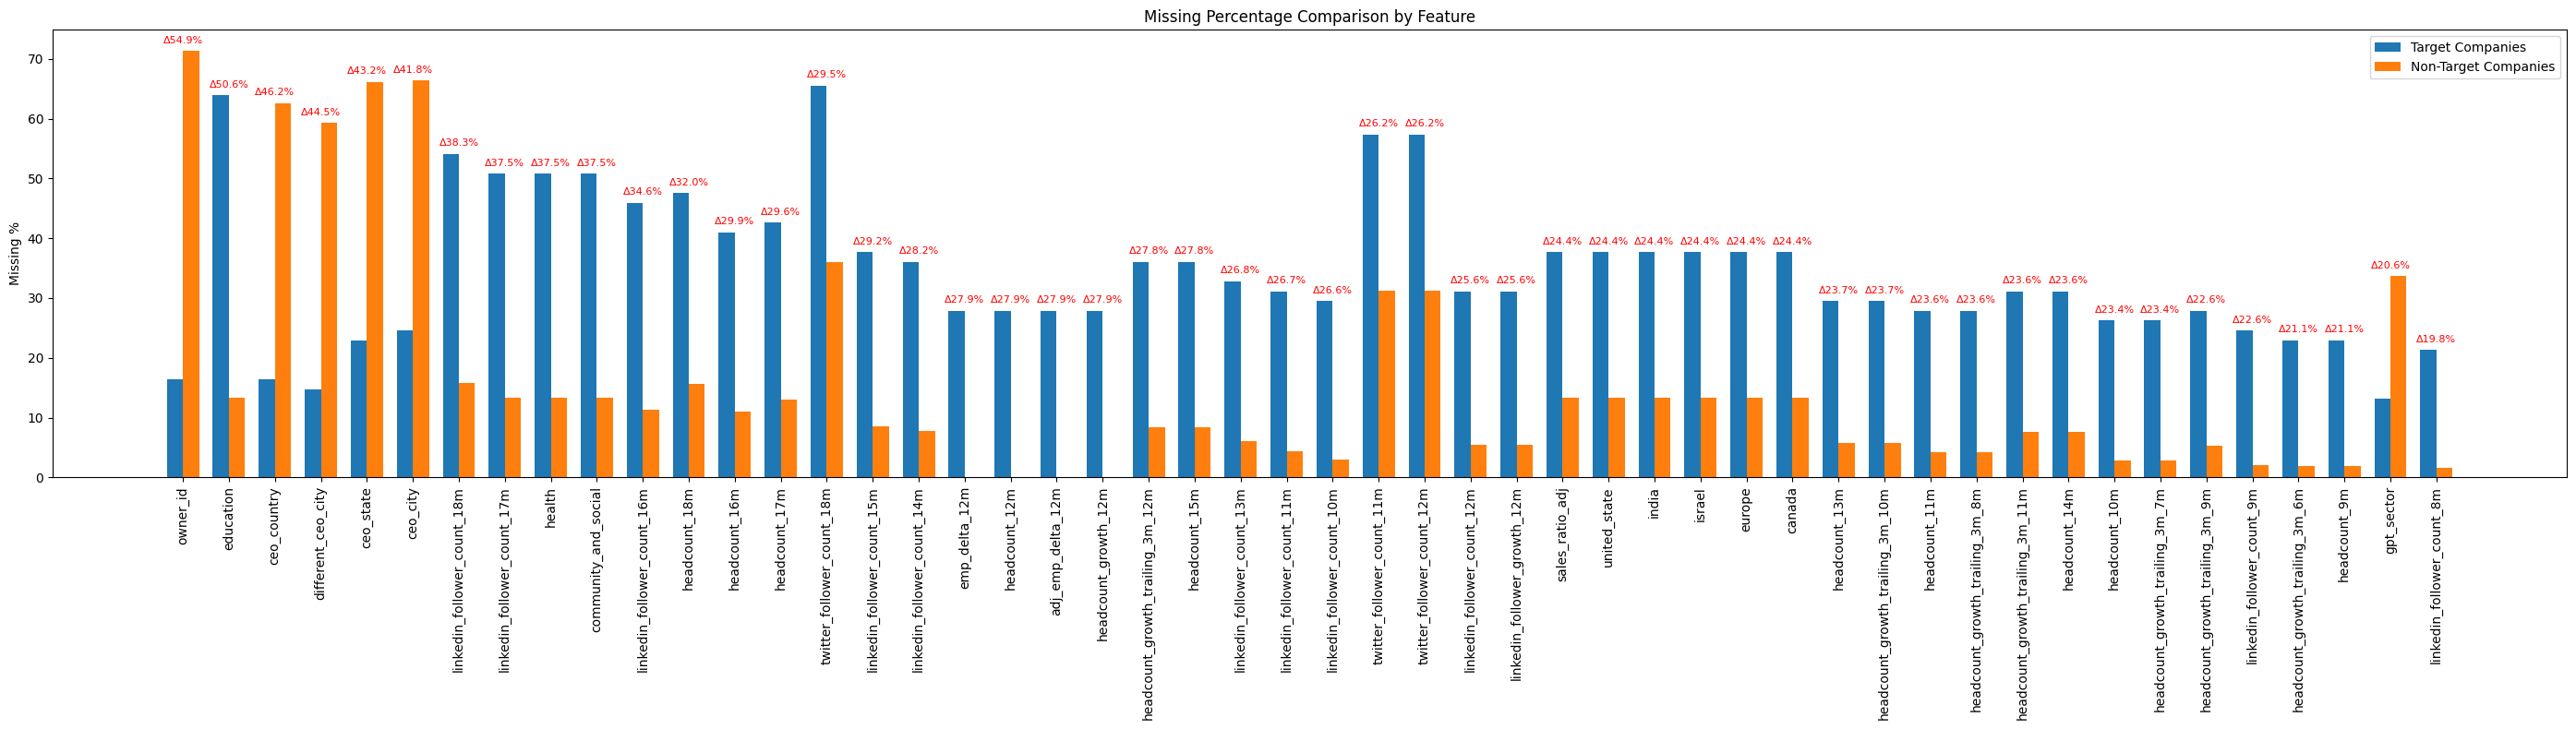

In [17]:
# Only show top N features with biggest missing % difference
top_n = 50
top_features = missing_comparison.head(top_n)

# Plot
x = np.arange(len(top_features))  # the label locations
width = 0.35  # width of the bars

fig, ax = plt.subplots(figsize=(28, 8))
rects1 = ax.bar(x - width/2, top_features['missing_pct_target'], width, label='Target Companies')
rects2 = ax.bar(x + width/2, top_features['missing_pct_non_target'], width, label='Non-Target Companies')

ax.set_ylabel('Missing %')
ax.set_title('Missing Percentage Comparison by Feature')
ax.set_xticks(x)
ax.set_xticklabels(top_features.index, rotation=90)
ax.legend()

for i, diff in enumerate(top_features['missing_pct_diff']):
    ax.text(i, max(top_features['missing_pct_target'].iloc[i], top_features['missing_pct_non_target'].iloc[i]) + 1,
            f"Δ{diff:.1f}%", ha='center', va='bottom', fontsize=8, color='red')

fig.tight_layout()
plt.show()

Usually when there’s a large imbalance in missing data between the target and non-target groups, the model can start using missingness as a shortcut to predict labels, instead of learning meaningful signals. 

Seeing that in the top 50 (greater than threshold for missing_pct_diff < 20) missing imbalanced features there are frequent occurrences of time series related features for headcount, emp_delta, linkedin follower count, and twitter follower count, I'll be keeping them as they are useful for feature engineering statistical aggregations out of them. 

Also for categorical features like education, community_and_social, health that seem to be a part of business function features I will also keep them for future feature engineering. 

The lowercased location features will also be kept because there is potential for feature engineering but I did notice that there were several other location related features some capitalized, some related to continents and so I need to do further analysis to determine which location features would be useful for the model to learn on. 

Now for ceo features they all seem to have a large missing imbalance between groups, so all ceo related features will be dropped.

Other stand-alone features that did not make the cut like owner_id, sales_ratio_adj, and gpt_sector will be dropped because:
- intuitively owner_id a feature used for identification generally is not helpful in training a model and in this case because its related to an owner it could also present as data leakage/creating biases if the model starts picking up that target companies tend to share certain owner ids.

- Moreover the sales_ratio_adj feature is a conversion probably used based on a company's main market/operation location so it's not going to tell us more than what a location feature would tell us about whether a company is similar/share characteristics to target companies.

- Lastly, although gpt_sector may seem useful but it would be better for the model to recognize a company's potential for investment through their patterns in getting funding and having a reasonable growth in employees and following rather than having a bias for a certain gpt_sector or industry. 

In [18]:
# Drop the features based on the explanation above
features_to_drop = ['ceo_country', 'different_ceo_city', 'ceo_state', 'ceo_city', 'owner_id', 'sales_ratio_adj', 'gpt_sector']
target_company_data.drop(columns=features_to_drop, inplace=True)
company_data.drop(columns=features_to_drop, inplace=True)

helper method

In [6]:
def plot_growth(metric, df, num_months=18, time_direction='backward'):
    month_cols = []
    
    if 'growth' in metric:
        month_cols = [f'{metric}_{m}m' for m in [1, 3, 6, 12]]
    else:
        month_cols = [f'{metric}_{m}m' for m in range(num_months + 1)]

    # Plot setup
    plt.figure(figsize=(8, 4))
    for i, row in df.iterrows():
        y = row[month_cols].apply(lambda x: np.nan if pd.isna(x) else x).values
        if 'growth' in metric:
            plt.plot([1, 3, 6, 12], y, alpha=0.4)
        else:
            plt.plot(range(num_months + 1), y, alpha=0.4)  # label only a few for clarity

    plt.xlabel('Months (0m = reference point)')
    plt.ylabel(f"{metric}")
    if time_direction == 'backward':
        plt.title(f'{metric} {num_months} Months Ago (n={len(df)})')
    else:
        plt.title(f'{metric} {num_months} Months in (n={len(df)})')
    plt.grid(True)
    plt.tight_layout()

# Time-series data

## Understand headcount features

In [7]:
target_headcount_features = target_company_data.filter(like='headcount')
target_headcount_features

,headcount,headcount_0m,headcount_1m,headcount_2m,headcount_3m,headcount_4m,headcount_5m,headcount_6m,headcount_7m,headcount_8m,...,headcount_growth_trailing_3m_7m,headcount_growth_trailing_3m_8m,headcount_growth_trailing_3m_9m,headcount_growth_trailing_3m_10m,headcount_growth_trailing_3m_11m,headcount_growth_trailing_3m_12m,headcount_monotonicity,headcount_concavity,max_headcount,adjusted_headcount
0,15,101,15.0,12.0,13.0,10.0,10.0,8.000000,9.0,8.0,...,1.285714,1.142857,1.000000,1.166667,1.166667,1.000000,0.916667,0.636364,31.0,30.6
1,18,215,19.0,21.0,21.0,15.0,15.0,15.000000,15.0,20.0,...,1.153846,1.818182,1.400000,1.625000,1.100000,1.250000,0.833333,0.545455,18.0,0.0
2,17,49,16.0,15.0,15.0,17.0,15.0,15.000000,13.0,12.0,...,1.300000,1.333333,1.375000,1.428571,1.500000,1.333333,0.750000,0.363636,27.0,22.9
3,11,79,11.0,5.0,NaN,NaN,NaN,10.312499,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.750000,0.545455,11.0,0.0
4,7,102,8.0,6.0,6.0,7.0,5.0,3.000000,3.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.250000,7.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,6,38,7.0,6.0,6.0,7.0,7.0,7.000000,7.0,7.0,...,0.700000,0.777778,1.142857,1.666667,1.500000,1.166667,0.333333,0.636364,16.0,16.0
57,19,19,NaN,NaN,NaN,NaN,NaN,17.812499,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.750000,0.545455,19.0,0.0
58,14,20,13.0,13.0,13.0,13.0,13.0,13.000000,13.0,13.0,...,1.000000,1.000000,1.083333,1.000000,1.083333,1.000000,0.250000,0.818182,15.0,14.2
59,13,31,14.0,12.0,12.0,10.0,10.0,11.000000,12.0,11.0,...,1.333333,1.375000,1.125000,1.125000,1.000000,1.142857,0.750000,0.636364,17.0,15.8


In [8]:
headcount_features = company_data.filter(like='headcount')
headcount_features

,headcount,headcount_0m,headcount_1m,headcount_2m,headcount_3m,headcount_4m,headcount_5m,headcount_6m,headcount_7m,headcount_8m,...,headcount_growth_trailing_3m_7m,headcount_growth_trailing_3m_8m,headcount_growth_trailing_3m_9m,headcount_growth_trailing_3m_10m,headcount_growth_trailing_3m_11m,headcount_growth_trailing_3m_12m,headcount_monotonicity,headcount_concavity,max_headcount,adjusted_headcount
0,15,15,18,17,17,15,10,9.000000,10,11,...,1.000000,1.571429,1.833333,1.666667,1.166667,1.000000,0.666667,0.454545,16.0,16.0
1,13,13,9,9,9,9,8,7.000000,7,8,...,1.750000,2.000000,1.750000,1.000000,1.333333,1.333333,0.666667,0.545455,13.0,9.9
4,10,10,11,11,11,11,12,12.000000,12,11,...,1.333333,1.833333,1.666667,1.500000,1.200000,1.200000,0.583333,0.545455,10.0,10.0
5,12,12,12,10,9,6,7,8.000000,7,6,...,NaN,NaN,NaN,NaN,NaN,NaN,0.833333,0.600000,12.0,0.0
6,15,15,17,14,14,14,12,12.000000,11,11,...,1.100000,1.375000,1.250000,1.250000,1.333333,1.600000,1.000000,0.545455,15.0,13.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15405,21,21,21,21,19,18,17,17.000000,16,16,...,1.066667,1.000000,1.000000,1.000000,1.066667,1.000000,0.750000,0.545455,23.0,23.0
15436,4,4,4,4,4,4,5,5.000000,6,6,...,0.857143,0.857143,0.500000,0.700000,0.538462,0.769231,0.000000,0.727273,4.0,0.0
15438,36,36,37,36,38,38,38,37.000000,38,37,...,1.055556,1.088235,1.125000,1.125000,0.971429,0.914286,0.583333,0.363636,36.0,0.0
15439,11,11,<NA>,<NA>,<NA>,<NA>,<NA>,8.777735,<NA>,<NA>,...,NaN,NaN,NaN,NaN,NaN,NaN,0.750000,0.545455,11.0,0.0


### headcount_xm

In [9]:
headcount_cols = [f'headcount_{i}m' for i in range(19)]

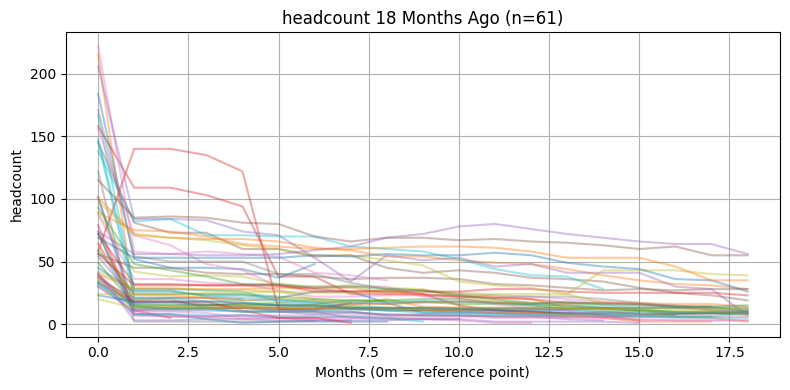

In [10]:
plot_growth('headcount', target_headcount_features)

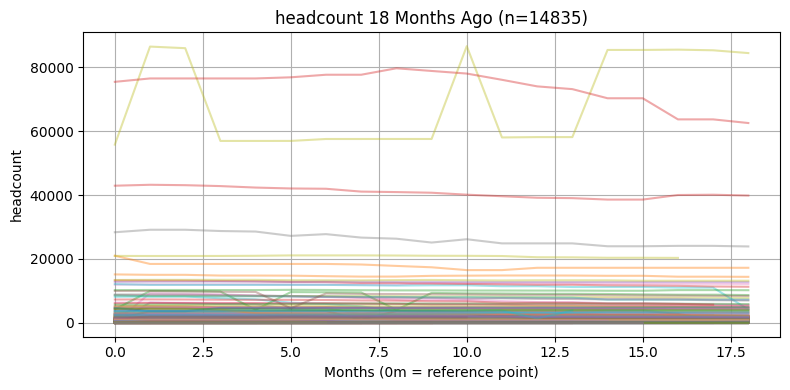

In [11]:
plot_growth('headcount', headcount_features)

### earliest_valid_month

In [12]:
def earliest_valid_month(row):
    for i in range(18, -1, -1):  # Start from oldest (18m) to newest (0m)
        if pd.isna(row[f'headcount_{i}m']):
            continue
        
        if not np.isnan(row[f'headcount_{i}m']):
            return i
    return np.nan  # if no valid headcount at all (very unlikely)


target_headcount_features = target_headcount_features.copy()
target_headcount_features['earliest_valid_month'] = target_headcount_features.apply(earliest_valid_month, axis=1)

headcount_features = headcount_features.copy()
headcount_features['earliest_valid_month'] = headcount_features.apply(earliest_valid_month, axis=1)

I wanted to find the earliest valid month for each company because it would capture how young or recently growing a startup is. If earliest valid month = 0m, it’s very new; if earliest valid month = 15m, it’s more established.

I did notice there was missing data for 1-5 months ago but the earliest valid month being 6, so I also want to add the feature num_valid_months to signal data completeness

### num_valid_months

In [13]:
target_headcount_features['num_valid_months'] = target_headcount_features[headcount_cols].notna().sum(axis=1)
headcount_features['num_valid_months'] = headcount_features[headcount_cols].notna().sum(axis=1)

### headcount_volatility_score
- calculating the coefficient of variation

- high std dev -> lots of fluctuation in headcount, counts are spread out from mean
- low std dev -> stable headcount, counts are close to mean

- we then need to divide the std dev by the mean in order to compare all company sizes on the same scale and keep the volatility score relative to the company's own size

In [14]:
def calculate_headcount_volatility_score(df):
    # Standard deviation and mean over 0m to 18m
    std_18m = df[headcount_cols].std(axis=1)
    mean_18m = df[headcount_cols].mean(axis=1)

    # Coefficient of Variation
    headcount_volatility_score_18m = std_18m / mean_18m

    return headcount_volatility_score_18m

In [15]:
target_headcount_features['headcount_volatility_score'] = calculate_headcount_volatility_score(target_headcount_features)
headcount_features['headcount_volatility_score'] = calculate_headcount_volatility_score(headcount_features)

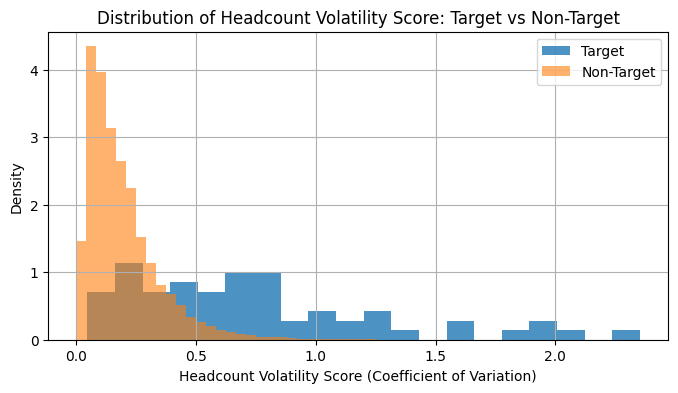

In [16]:
plt.figure(figsize=(8, 4))
# density = true, normalizes the histogram around to area = 1 (so we can compare shape and not absolute counts)
plt.hist(target_headcount_features['headcount_volatility_score'].dropna(), bins=20, alpha=0.8, label='Target', density=True)
plt.hist(headcount_features['headcount_volatility_score'], bins=50, alpha=0.6, label='Non-Target', density=True)
plt.xlabel('Headcount Volatility Score (Coefficient of Variation)')
plt.ylabel('Density')
plt.title('Distribution of Headcount Volatility Score: Target vs Non-Target')
plt.legend()
plt.grid(True)
plt.show()

### headcount_growthxm

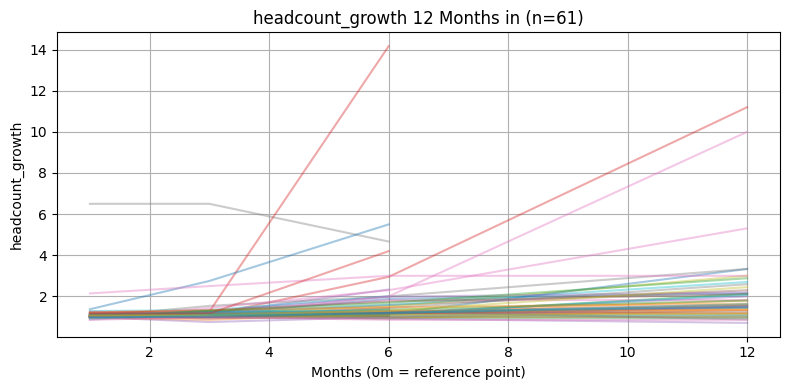

In [17]:
plot_growth('headcount_growth', target_headcount_features, num_months=12, time_direction='forward')

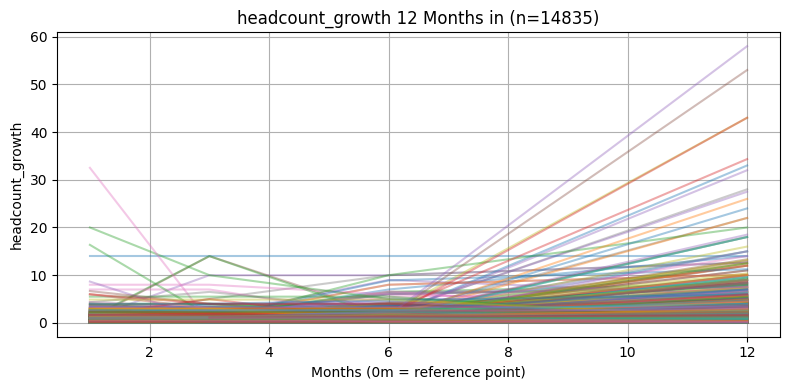

In [18]:
plot_growth('headcount_growth', headcount_features, num_months=12, time_direction='forward')

### headcount_growth_trailing_3m_xm
- From x+3 months ago to x months ago, how much did the headcount grow (%)?

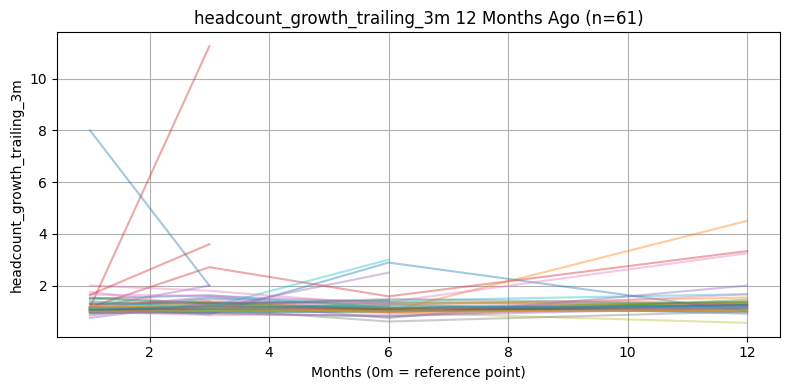

In [19]:
plot_growth('headcount_growth_trailing_3m', target_headcount_features, num_months=12, time_direction='backward')

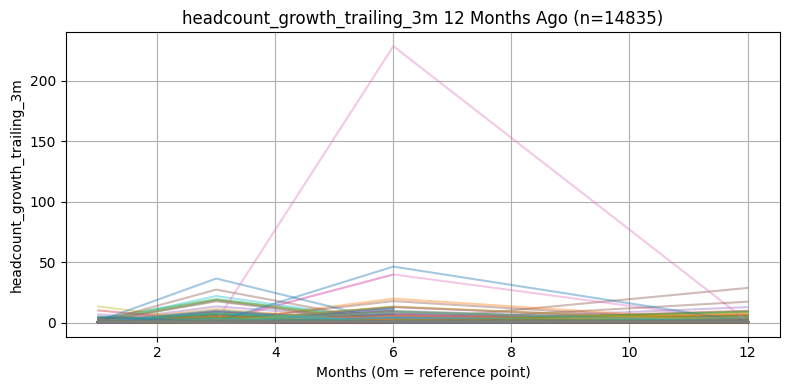

In [20]:
plot_growth('headcount_growth_trailing_3m', headcount_features, num_months=12, time_direction='backward')

In [21]:
def trailing_growth_features(df):
    trailing_cols = [col for col in df.columns if 'headcount_growth_trailing_3m' in col]

    df['trailing_growth_avg'] = df[trailing_cols].mean(axis=1)
    df['trailing_growth_std'] = df[trailing_cols].std(axis=1)
    df['trailing_growth_min'] = df[trailing_cols].min(axis=1)
    df['trailing_growth_max'] = df[trailing_cols].max(axis=1)

    return df

target_headcount_features = trailing_growth_features(target_headcount_features)
headcount_features = trailing_growth_features(headcount_features)


### headcount_monotonicity
- How consistently headcount moves in one direction over time
- A higher monotonicity suggests steady hiring → momentum, low churn, positive growth.
- A low monotonicity might mean layoffs, instability, pivoting — red flags for investors.

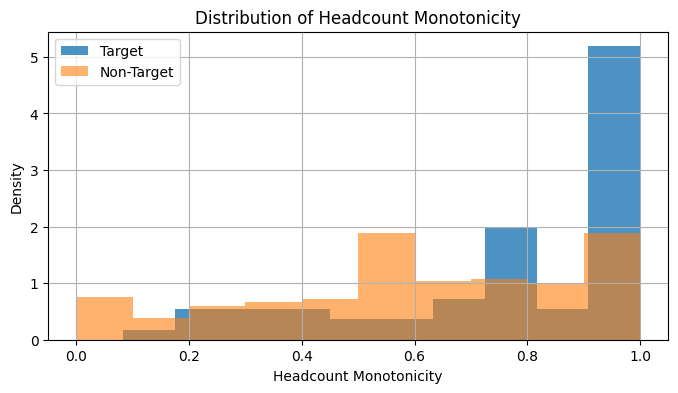

In [22]:
plt.figure(figsize=(8, 4))
plt.hist(target_headcount_features['headcount_monotonicity'], bins=10, label='Target', density=True, alpha=0.8)
plt.hist(headcount_features['headcount_monotonicity'], bins=10, label='Non-Target', density=True, alpha=0.6)
plt.xlabel('Headcount Monotonicity')
plt.ylabel('Density')
plt.title('Distribution of Headcount Monotonicity')
plt.legend()
plt.grid(True)
plt.show()

### headcount_concavity
- How much the hiring rate itself is speeding up
- High concavity → startup is gaining momentum
- Low concavity → startup may be slowing or maturing too soon

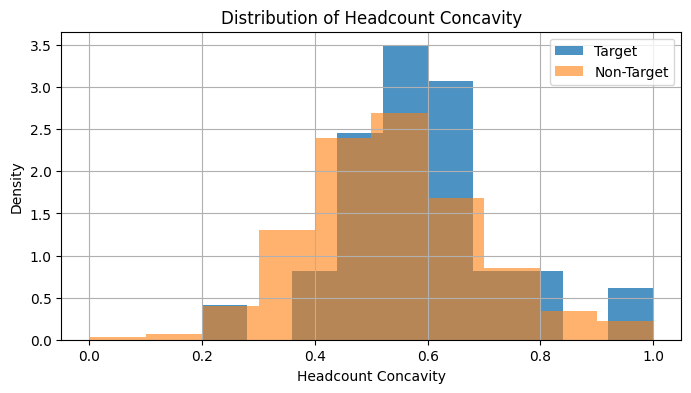

In [23]:
plt.figure(figsize=(8, 4))
plt.hist(target_headcount_features['headcount_concavity'], bins=10, label='Target', density=True, alpha=0.8)
plt.hist(headcount_features['headcount_concavity'], bins=10, label='Non-Target', density=True, alpha=0.6)
plt.xlabel('Headcount Concavity')
plt.ylabel('Density')
plt.title('Distribution of Headcount Concavity')
plt.legend()
plt.grid(True)
plt.show()

### headcount current/max ratio
- (Concavity,	Current/Max Ratio)
    - (High, Low) -> Was growing fast, now shrank heavily (possible layoffs)
    - (Low, High) -> Grew fast early, stayed big and stable
    - (High, High) -> Explosive growth, still at peak — ideal
    - (Low, Low) -> Early growth, then faded — risky

In [24]:
def calculate_current_max_ratio(row):
    if row['max_headcount'] == 0 or pd.isna(row['max_headcount']):
        return 0
    else:
        return row['headcount_0m'] / row['max_headcount']

target_headcount_features['current_max_ratio'] = target_headcount_features.apply(calculate_current_max_ratio, axis=1)
headcount_features['current_max_ratio'] = headcount_features.apply(calculate_current_max_ratio, axis=1)

In [25]:
target_headcount_features.drop(columns=headcount_cols[1:], inplace=True)
headcount_features.drop(columns=headcount_cols[1:], inplace=True)

target_headcount_features.drop(columns=[col for col in target_headcount_features.columns if 'headcount_growth_trailing_3m' in col], inplace=True)
headcount_features.drop(columns=[col for col in headcount_features.columns if 'headcount_growth_trailing_3m' in col], inplace=True)

target_headcount_features.drop(columns=['headcount', 'adjusted_headcount'], inplace=True) # headcount_0m is more consistent between target and non-target
headcount_features.drop(columns=['headcount', 'adjusted_headcount'], inplace=True)

In [26]:
print("Final Target Headcount Features:", target_headcount_features.columns.tolist())
print("Final Non-Target Headcount Features:", headcount_features.columns.tolist())

Final Target Headcount Features: ['headcount_0m', 'headcount_growth_1m', 'headcount_growth_3m', 'headcount_growth_6m', 'headcount_growth_12m', 'headcount_monotonicity', 'headcount_concavity', 'max_headcount', 'earliest_valid_month', 'num_valid_months', 'headcount_volatility_score', 'trailing_growth_avg', 'trailing_growth_std', 'trailing_growth_min', 'trailing_growth_max', 'current_max_ratio']
Final Non-Target Headcount Features: ['headcount_0m', 'headcount_growth_1m', 'headcount_growth_3m', 'headcount_growth_6m', 'headcount_growth_12m', 'headcount_monotonicity', 'headcount_concavity', 'max_headcount', 'earliest_valid_month', 'num_valid_months', 'headcount_volatility_score', 'trailing_growth_avg', 'trailing_growth_std', 'trailing_growth_min', 'trailing_growth_max', 'current_max_ratio']


## Understand linkedin features

In [27]:
target_linkedin_features = target_company_data.filter(like='linkedin')
target_linkedin_features

,linkedin_follower_count,linkedin_url_harmonic,linkedin_follower_count_0m,linkedin_follower_count_1m,linkedin_follower_count_2m,linkedin_follower_count_3m,linkedin_follower_count_4m,linkedin_follower_count_5m,linkedin_follower_count_6m,linkedin_follower_count_7m,...,linkedin_follower_count_16m,linkedin_follower_count_17m,linkedin_follower_count_18m,linkedin_follower_growth_1m,linkedin_follower_growth_3m,linkedin_follower_growth_6m,linkedin_follower_growth_12m,linkedin_url_linkedin,linkedin_company,linkedin_employees
0,2076,https://linkedin.com/company/hebbia,23548,1652.0,1134.0,928.0,606.0,584.0,545.0,500.0,...,107.0,106.0,95.0,1.256659,2.237069,3.809174,12.814815,https://linkedin.com/company/hebbia,hebbia,31.0
1,739,https://linkedin.com/company/axion-ray,3834,718.0,679.0,679.0,559.0,559.0,537.0,526.0,...,49.0,44.0,33.0,1.029248,1.088365,1.376164,1.806846,None,axion-ray,0.0
2,1590,https://linkedin.com/company/syrup-tech,5935,1553.0,1515.0,1447.0,1395.0,1343.0,1254.0,1232.0,...,850.0,808.0,NaN,1.023825,1.098825,1.267943,1.524449,https://www.linkedin.com/company/syrup-tech/,syrup-tech,27.0
3,262,https://linkedin.com/company/unstructuredio,17285,244.0,188.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.073771,NaN,NaN,NaN,None,unstructuredio,0.0
4,121,https://linkedin.com/company/smarterdx,3744,112.0,82.0,82.0,68.0,59.0,54.0,41.0,...,NaN,NaN,NaN,1.080357,1.475610,2.240741,NaN,None,smarterdx,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,358,https://linkedin.com/company/siro-ai,2130,356.0,354.0,354.0,351.0,333.0,333.0,333.0,...,90.0,88.0,84.0,1.005618,1.011299,1.075075,1.549784,https://www.linkedin.com/company/siro-ai/,siro-ai,16.0
57,1412,https://linkedin.com/company/browserbasehq,1412,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,browserbasehq,0.0
58,208,https://linkedin.com/company/pomerium-inc,1717,195.0,195.0,192.0,199.0,196.0,194.0,187.0,...,142.0,137.0,136.0,1.066667,1.083333,1.072165,1.291925,https://linkedin.com/company/pomerium-inc,pomerium-inc,15.0
59,926,https://linkedin.com/company/tavus-io,8385,890.0,822.0,822.0,797.0,715.0,706.0,695.0,...,404.0,397.0,359.0,1.040449,1.126521,1.311615,1.636042,https://www.linkedin.com/company/tavus-io/,tavus-io,17.0


In [28]:
linkedin_features = company_data.filter(like='linkedin')
linkedin_features

,linkedin_follower_count,linkedin_url_harmonic,linkedin_follower_count_0m,linkedin_follower_count_1m,linkedin_follower_count_2m,linkedin_follower_count_3m,linkedin_follower_count_4m,linkedin_follower_count_5m,linkedin_follower_count_6m,linkedin_follower_count_7m,...,linkedin_follower_count_16m,linkedin_follower_count_17m,linkedin_follower_count_18m,linkedin_follower_growth_1m,linkedin_follower_growth_3m,linkedin_follower_growth_6m,linkedin_follower_growth_12m,linkedin_url_linkedin,linkedin_company,linkedin_employees
0,3228,https://linkedin.com/company/keye,3228,3139,2756,1722,1680,1667,1649,1636,...,1421,1420,1407,1.028353,1.874564,1.957550,2.189959,https://linkedin.com/company/keye,keye,16.0
1,6775,https://linkedin.com/company/stackai,6775,6775,6775,6775,6775,6227,5666,5192,...,2063,1837,1510,1.000000,1.000000,1.195729,2.435298,https://linkedin.com/company/stackai,stackai,10.0
4,1121,https://linkedin.com/company/extend-app,1121,1098,1047,971,901,846,703,688,...,494,468,<NA>,1.020947,1.154480,1.594595,2.123106,https://linkedin.com/company/extend-app,extend-app,10.0
5,1140,https://linkedin.com/company/hamming-ai,1140,1140,689,567,422,181,141,119,...,<NA>,<NA>,<NA>,1.000000,2.010582,8.085107,NaN,<NA>,hamming-ai,0.0
6,1345,https://linkedin.com/company/vooma-inc,1345,1345,744,673,647,603,544,528,...,263,236,174,1.000000,1.998514,2.472426,3.493506,https://linkedin.com/company/vooma-inc,vooma-inc,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15405,4400,https://linkedin.com/company/the-leap-partners,4400,4402,4404,4233,3742,3761,3761,3766,...,689,679,630,0.999546,1.039452,1.169902,4.522097,https://linkedin.com/company/the-leap-partners,the-leap-partners,23.0
15436,1208,https://linkedin.com/company/datajoin,1208,1207,1206,1207,1205,1201,1194,1194,...,1189,1183,1182,1.000829,1.000829,1.011725,1.036021,<NA>,datajoin,0.0
15438,1460,https://linkedin.com/company/topquadrant,1460,1460,1449,1428,1416,1399,1347,1319,...,1067,1032,1018,1.000000,1.022409,1.083890,1.279579,<NA>,topquadrant,0.0
15439,1073,https://linkedin.com/company/seamai,1073,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,NaN,NaN,NaN,NaN,<NA>,seamai,0.0


In [29]:
target_linkedin_features = target_linkedin_features.copy()
linkedin_features = linkedin_features.copy()

target_linkedin_follower_counts = target_linkedin_features[[f'linkedin_follower_count_{i}m' for i in range(0, 19)]]
linkedin_follower_counts = linkedin_features[[f'linkedin_follower_count_{i}m' for i in range(0, 19)]]

### linkedin_follower_count_xm

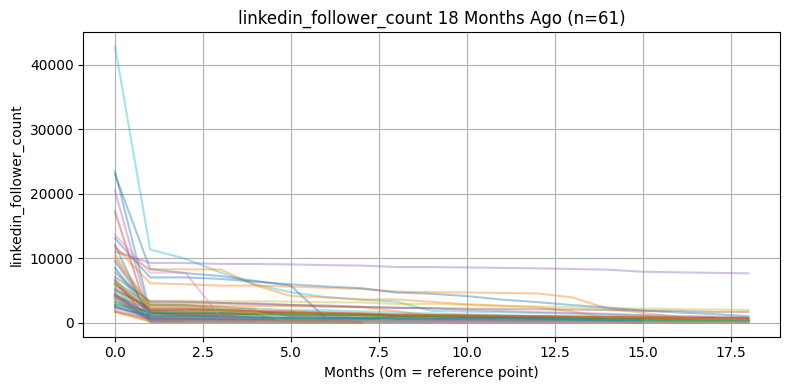

In [30]:
plot_growth('linkedin_follower_count', target_linkedin_features, num_months=18)

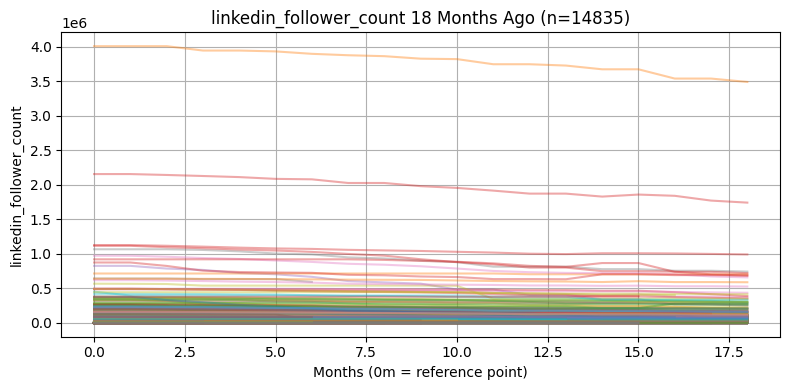

In [31]:
plot_growth('linkedin_follower_count', linkedin_features, num_months=18)

### linkedin_follower_count_max

In [32]:
target_linkedin_features['linkedin_follower_count_max'] = target_linkedin_follower_counts.max(axis=1)
linkedin_features['linkedin_follower_count_max'] = linkedin_follower_counts.max(axis=1)

### linkedin_follower_peak_month
- peak_month tells you how far back the company's hype peak was
- very useful for spotting decliners vs still-growing companies



In [33]:
target_linkedin_features['linkedin_follower_peak_month'] = target_linkedin_follower_counts.idxmax(axis=1).str.extract('(\d+)').astype(float).astype('Int64')
linkedin_features['linkedin_follower_peak_month'] = linkedin_follower_counts.idxmax(axis=1).str.extract('(\d+)').astype(float).astype('Int64')

### linkedin_current_peak_count_ratio
- how much of the maximum follower attention the startup still retains today

In [34]:
target_linkedin_features['linkedin_current_peak_count_ratio'] = target_linkedin_features['linkedin_follower_count_0m'] / target_linkedin_features['linkedin_follower_count_max']
linkedin_features['linkedin_current_peak_count_ratio'] = linkedin_features['linkedin_follower_count_0m'] / linkedin_features['linkedin_follower_count_max']

### linkedin_follower_count_volatility 
- high volatility 
    - in a positive light can indicate the company is exciting, fast-moving, and could be a breakout success
    - in a negative light can indicate the company is overhyped and unstable

- low volatility
    - in a positive light can indicate the company is reliable or under the rader but solid
    - in a negative light can indicate the company is has no public traction

In [35]:
target_linkedin_features['linkedin_follower_count_volatility'] = target_linkedin_follower_counts.std(axis=1)
linkedin_features['linkedin_follower_count_volatility'] = linkedin_follower_counts.std(axis=1)

### linkedin_follower_trend
- determines the global, consistent direction of public attention, not just short bursts we have accounted through linkedin_follower_growth_xm.

In [36]:
def calculate_follower_trend(row, social_media, min_valid_months=12):
    months = np.arange(19)[::-1]  # Reverse order for trend calculation (0m to 18m)
    follower_counts = row[[f'{social_media}_follower_count_{i}m' for i in range(19)]].values

    follower_counts = pd.to_numeric(follower_counts, errors='coerce').astype(float)  # Ensure all values are numeric, coercing errors to NaN
    
    # Count non-missing months
    num_valid_months = np.isfinite(follower_counts).sum()
    
    if num_valid_months < min_valid_months:
        return np.nan  # Too little real data, skip
    
    # Interpolate missing values
    follower_counts = pd.Series(follower_counts).interpolate(method='linear', limit_direction='both').values
    
    slope, _ = np.polyfit(months, follower_counts, deg=1) # deg = 1 to fit a line, so its capturing the overall trend and not every single fluctuation
    return slope

target_linkedin_features['linkedin_follower_trend'] = target_linkedin_features.apply(calculate_follower_trend, args=('linkedin',), axis=1)
linkedin_features['linkedin_follower_trend'] = linkedin_features.apply(calculate_follower_trend, args=('linkedin',), axis=1)

### followers_per_linkedin_employee
- a very high followers/employee ratio often hints at:
    - good marketing
    - virality
    - consumer brand appeal

- a very low ratio may suggest:
    - B2B (more niche audience)
    - early stage, stealth mode
    - lack of marketing investment

- the ratio is then normalized because company size matters:
    - a startup with 10 employees and 5,000 followers (500 followers/employee) is impressive.
    - a company with 1,000 employees and 5,000 followers (5 followers/employee) is not impressive — it’s actually weak.

In [37]:
def calculate_followers_per_linkedin_employee(row):
    # Get current follower count and employee count
    current_followers = row['linkedin_follower_count_0m']
    employee_count = row['linkedin_employees']
    
    # Handle division carefully
    if pd.isna(current_followers) or pd.isna(employee_count) or employee_count <= 0:
        return np.nan  # Avoid divide-by-zero or missing values
    else:
        return current_followers / employee_count
    
target_linkedin_features['followers_per_linkedin_employee'] = target_linkedin_features.apply(calculate_followers_per_linkedin_employee, axis=1)
linkedin_features['followers_per_linkedin_employee'] = linkedin_features.apply(calculate_followers_per_linkedin_employee, axis=1)

target_linkedin_features['followers_per_linkedin_employee'] = np.log1p(target_linkedin_features['followers_per_linkedin_employee'])
linkedin_features['followers_per_linkedin_employee'] = np.log1p(linkedin_features['followers_per_linkedin_employee'])

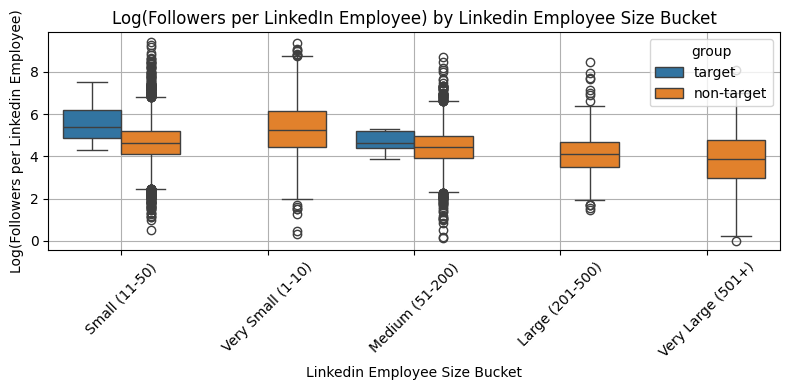

In [38]:
# bucket companies by LinkedIn employee size
def linkedin_employee_size_bucket(emp_count):
    if emp_count <= 10:
        return 'Very Small (1-10)'
    elif emp_count <= 50:
        return 'Small (11-50)'
    elif emp_count <= 200:
        return 'Medium (51-200)'
    elif emp_count <= 500:
        return 'Large (201-500)'
    else:
        return 'Very Large (501+)'
    
target_linkedin_employee_df = target_linkedin_features[['followers_per_linkedin_employee']].copy()
target_linkedin_employee_df['linkedin_employee_size_bucket'] = target_linkedin_features['linkedin_employees'].apply(linkedin_employee_size_bucket)
linkedin_employee_df = linkedin_features[['followers_per_linkedin_employee']].copy()
linkedin_employee_df['linkedin_employee_size_bucket'] = linkedin_features['linkedin_employees'].apply(linkedin_employee_size_bucket)

combined_df = pd.concat([
    target_linkedin_employee_df.assign(group='target'),
    linkedin_employee_df.assign(group='non-target')
], ignore_index=True)

plt.figure(figsize=(8, 4))
sns.boxplot(
    data=combined_df,
    x='linkedin_employee_size_bucket',
    y='followers_per_linkedin_employee',
    hue='group'
)
plt.title('Log(Followers per LinkedIn Employee) by Linkedin Employee Size Bucket')
plt.xlabel('Linkedin Employee Size Bucket')
plt.ylabel('Log(Followers per Linkedin Employee)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### linkedin_follower_growth_xm

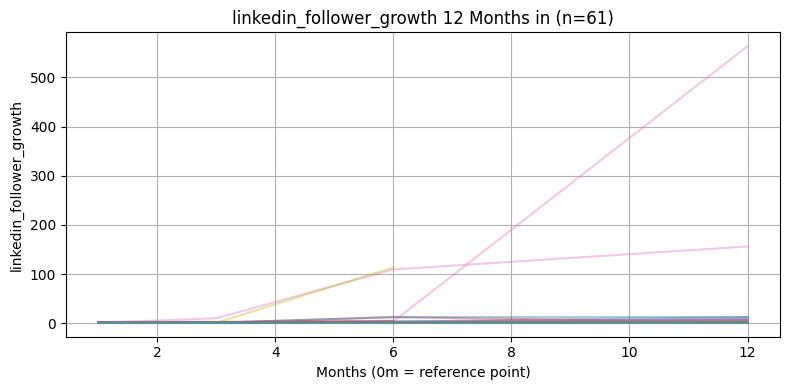

In [39]:
plot_growth('linkedin_follower_growth', target_linkedin_features, num_months=12, time_direction='forward')

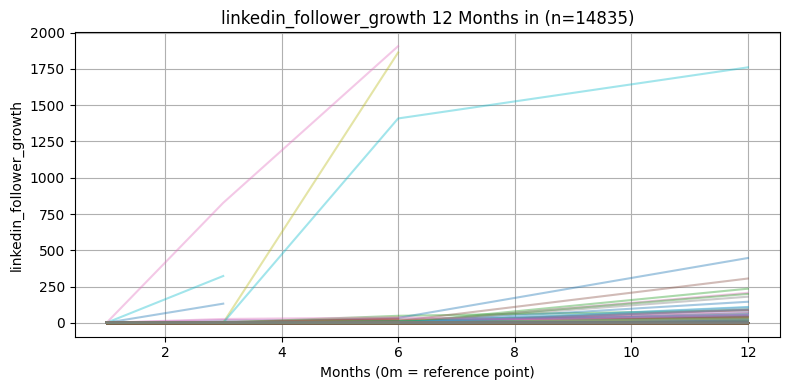

In [40]:
plot_growth('linkedin_follower_growth', linkedin_features, num_months=12, time_direction='forward')

In [41]:
target_linkedin_features.drop(columns=[f'linkedin_follower_count_{i}m' for i in range(1, 19)], inplace=True)
linkedin_features.drop(columns=[f'linkedin_follower_count_{i}m' for i in range(1, 19)], inplace=True)

target_linkedin_features.drop(columns=['linkedin_url_linkedin', 'linkedin_company', 'linkedin_url_harmonic', 'linkedin_follower_count'], inplace=True)
linkedin_features.drop(columns=['linkedin_url_linkedin', 'linkedin_company', 'linkedin_url_harmonic', 'linkedin_follower_count'], inplace=True)

print("Final Target LinkedIn Features:", target_linkedin_features.columns.tolist())
print("Final Non-Target LinkedIn Features:", linkedin_features.columns.tolist())

Final Target LinkedIn Features: ['linkedin_follower_count_0m', 'linkedin_follower_growth_1m', 'linkedin_follower_growth_3m', 'linkedin_follower_growth_6m', 'linkedin_follower_growth_12m', 'linkedin_employees', 'linkedin_follower_count_max', 'linkedin_follower_peak_month', 'linkedin_current_peak_count_ratio', 'linkedin_follower_count_volatility', 'linkedin_follower_trend', 'followers_per_linkedin_employee']
Final Non-Target LinkedIn Features: ['linkedin_follower_count_0m', 'linkedin_follower_growth_1m', 'linkedin_follower_growth_3m', 'linkedin_follower_growth_6m', 'linkedin_follower_growth_12m', 'linkedin_employees', 'linkedin_follower_count_max', 'linkedin_follower_peak_month', 'linkedin_current_peak_count_ratio', 'linkedin_follower_count_volatility', 'linkedin_follower_trend', 'followers_per_linkedin_employee']


## Understand twitter features

In [42]:
target_twitter_features = target_company_data.filter(like='twitter')
target_twitter_features

,twitter_follower_count,twitter_follower_count_0m,twitter_follower_count_1m,twitter_follower_count_2m,twitter_follower_count_3m,twitter_follower_count_4m,twitter_follower_count_5m,twitter_follower_count_6m,twitter_follower_count_7m,twitter_follower_count_8m,twitter_follower_count_9m,twitter_follower_count_10m,twitter_follower_count_11m,twitter_follower_count_12m,twitter_follower_count_13m,twitter_follower_count_14m,twitter_follower_count_15m,twitter_follower_count_16m,twitter_follower_count_17m,twitter_follower_count_18m
0,617.0,4562.0,610.0,508.0,485.0,427.0,411.0,403.0,403.0,398.0,392.0,391.0,NaN,393.0,380.0,368.0,328.0,231.0,201.0,191.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,22.0,5306.0,21.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57,3728.0,3728.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58,200.0,209.0,200.0,200.0,202.0,202.0,202.0,202.0,196.0,196.0,196.0,195.0,192.0,190.0,171.0,171.0,171.0,171.0,171.0,166.0
59,NaN,1339.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
twitter_features = company_data.filter(like='twitter')
twitter_features

,twitter_follower_count,twitter_follower_count_0m,twitter_follower_count_1m,twitter_follower_count_2m,twitter_follower_count_3m,twitter_follower_count_4m,twitter_follower_count_5m,twitter_follower_count_6m,twitter_follower_count_7m,twitter_follower_count_8m,twitter_follower_count_9m,twitter_follower_count_10m,twitter_follower_count_11m,twitter_follower_count_12m,twitter_follower_count_13m,twitter_follower_count_14m,twitter_follower_count_15m,twitter_follower_count_16m,twitter_follower_count_17m,twitter_follower_count_18m
0,22,22.0,22.0,22.0,22.0,22.0,22.0,22.0,22.0,22.0,22.0,22.0,22.0,22.0,22.0,23.0,23.0,23.0,22.0,18.0
1,3905,3905.0,3905.0,3842.0,3517.0,3462.0,3237.0,3186.0,2957.0,2679.0,2457.0,1115.0,1115.0,1115.0,1115.0,1024.0,1024.0,812.0,200.0,200.0
4,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15405,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15436,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15438,1795,1795.0,1795.0,1795.0,1795.0,1795.0,1795.0,1795.0,1795.0,1795.0,1795.0,1795.0,1795.0,1795.0,1795.0,1797.0,1797.0,1804.0,1804.0,1804.0
15439,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
target_twitter_features = target_twitter_features.copy()
twitter_features = twitter_features.copy()

target_twitter_follower_counts = target_twitter_features[[f'twitter_follower_count_{i}m' for i in range(0, 19)]]
twitter_follower_counts = twitter_features[[f'twitter_follower_count_{i}m' for i in range(0, 19)]]

### twitter_follower_count_xm

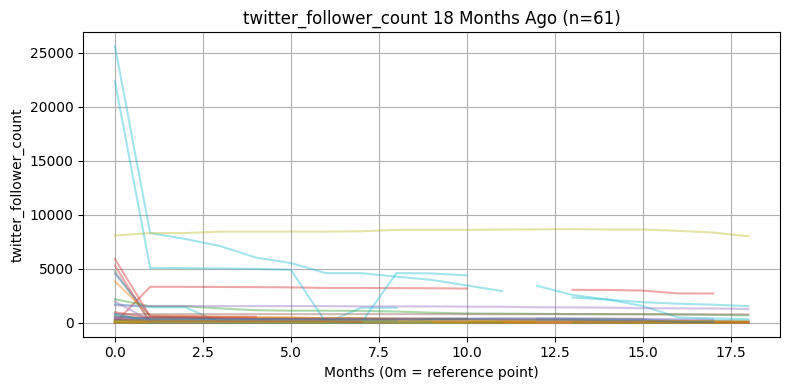

In [45]:
plot_growth('twitter_follower_count', target_twitter_features, num_months=18)

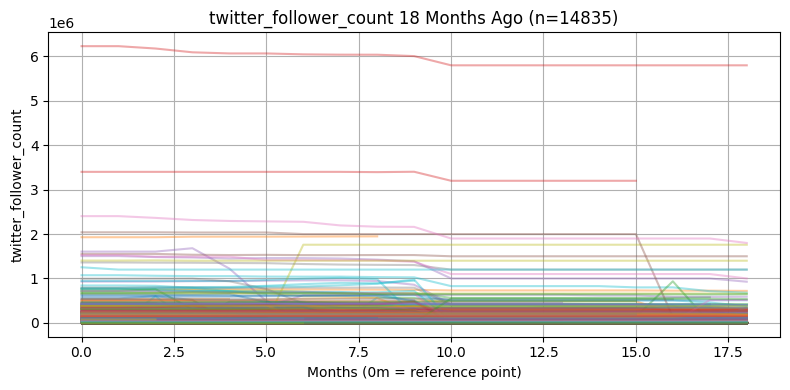

In [46]:
plot_growth('twitter_follower_count', twitter_features, num_months=18)

### twitter_follower_count_max
- reflects their peak popularity
- companies with high maximums may have once gone viral, or had significant public attention

In [47]:
target_twitter_features['twitter_follower_count_max'] = target_twitter_follower_counts.max(axis=1)
twitter_features['twitter_follower_count_max'] = twitter_follower_counts.max(axis=1)

### twitter_follower_count_peak_month
- tells you when their brand was strongest
- if a company peaked long ago and is declining, it might not be growing anymore
- if the peak is recent (near 0m), it suggests momentum and fresh attention

In [48]:
target_twitter_features['twitter_follower_peak_month'] = target_twitter_follower_counts.idxmax(axis=1).str.extract('(\d+)').astype(float).astype('Int64')
twitter_features['twitter_follower_peak_month'] = twitter_follower_counts.idxmax(axis=1).str.extract('(\d+)').astype(float).astype('Int64')

### twitter_current_peak_ratio
- helps detect companies that are declining vs still hot

In [49]:
target_twitter_features['twitter_current_peak_ratio'] = target_twitter_features['twitter_follower_count_0m'] / target_twitter_features['twitter_follower_count_max']
twitter_features['twitter_current_peak_ratio'] = twitter_features['twitter_follower_count_0m'] / twitter_features['twitter_follower_count_max']

### twitter_follower_count_volatility
- high volatility → unstable follower growth (virality spikes)
- low volatility → consistent, reliable follower trends

In [50]:
target_twitter_features['twitter_follower_count_volatility'] = target_twitter_follower_counts.std(axis=1)
twitter_features['twitter_follower_count_volatility'] = twitter_follower_counts.std(axis=1)

### twitter_follower_trend
- positive slope → consistently gaining followers (growing brand)
- negative slope → losing followers over time (fading relevance)
- near-zero slope → stagnant growth
- captures momentum better than just looking at two points in time

In [51]:
target_twitter_features['twitter_follower_trend'] = target_twitter_features.apply(calculate_follower_trend, args=('twitter',), axis=1)
twitter_features['twitter_follower_trend'] = twitter_features.apply(calculate_follower_trend, args=('twitter',), axis=1)

In [52]:
target_twitter_features.drop(columns=[f'twitter_follower_count_{i}m' for i in range(1, 19)], inplace=True)
twitter_features.drop(columns=[f'twitter_follower_count_{i}m' for i in range(1, 19)], inplace=True)

target_twitter_features.drop(columns=['twitter_follower_count'], inplace=True)
twitter_features.drop(columns=['twitter_follower_count'], inplace=True)

print("Final Target Twitter Features:", target_twitter_features.columns.tolist())
print("Final Non-Target Twitter Features:", twitter_features.columns.tolist())

Final Target Twitter Features: ['twitter_follower_count_0m', 'twitter_follower_count_max', 'twitter_follower_peak_month', 'twitter_current_peak_ratio', 'twitter_follower_count_volatility', 'twitter_follower_trend']
Final Non-Target Twitter Features: ['twitter_follower_count_0m', 'twitter_follower_count_max', 'twitter_follower_peak_month', 'twitter_current_peak_ratio', 'twitter_follower_count_volatility', 'twitter_follower_trend']


## Understand employee features

In [89]:
target_employee_features = target_company_data.filter(regex=r'emps?[_|/]', axis=1).copy()
employee_features = company_data.filter(regex=r'emps?[_|/]', axis=1).copy()

In [60]:
def plot_kde(data, x):
    plt.figure(figsize=(4,3))
     # because we have a huge class imbalance,
     # common_norm=False will not normalize the KDEs to the same area
     # to show us the shape of the distributions and not the absolute counts
    sns.kdeplot(data=data, x=x, hue='label', common_norm=False)
    plt.title(f'Distribution of {x} by Target vs Non-target')
    plt.grid(True)
    plt.show()

In [74]:
def log_transform_deltas(df, delta_cols):
    """
    Safely log-transform delta features that may have negative values by shifting them.
    """
    # Find the overall minimum value among all delta columns (consistent scale)
    min_val = df[delta_cols].min().min()

    # Determine the shift needed
    shift = 0
    if min_val <= -1:
        shift = abs(min_val) + 1.01  # Make sure everything > 0 for log1p

    # Apply the shift and log1p
    for col in delta_cols:
        df[f'log_{col}'] = np.log1p(df[col] + shift)

In [90]:
target_employee_features['label'] = 'target'
employee_features['label'] = 'non-target'

employee_features_combined = pd.concat([target_employee_features, employee_features], ignore_index=True)

In [91]:
from scipy.stats.mstats import winsorize

log_transform_deltas(employee_features_combined, 
                      delta_cols=['emp_delta_6m', 'adj_emp_delta_6m', 'emp_delta_12m', 'adj_emp_delta_12m'])

# Even after shifting and log-transforming, some companies might still have much larger growth spikes compared to most others.

# Winsorization is a softer clipping done statistically.
# Instead of removing or slicing data, it replaces extreme values with the nearest value inside the limits.
for col in ['log_emp_delta_6m', 'log_adj_emp_delta_6m', 'log_emp_delta_12m', 'log_adj_emp_delta_12m']:
    # Winsorize: limit 1% at each tail
    employee_features_combined[f'winsorized_{col}'] = winsorize(employee_features_combined[col], limits=[0.01, 0.01])

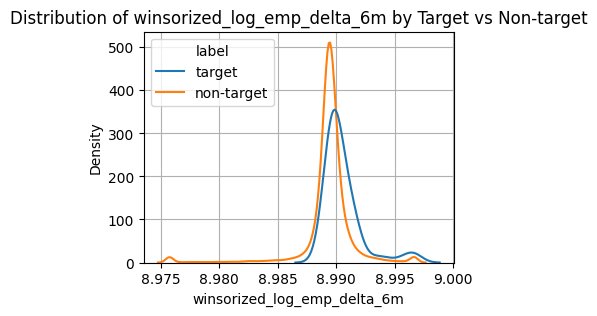

In [84]:
plot_kde(employee_features_combined, 'winsorized_log_emp_delta_6m')

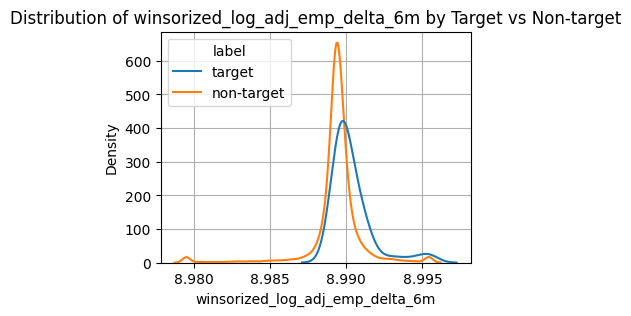

In [85]:
plot_kde(employee_features_combined, 'winsorized_log_adj_emp_delta_6m')

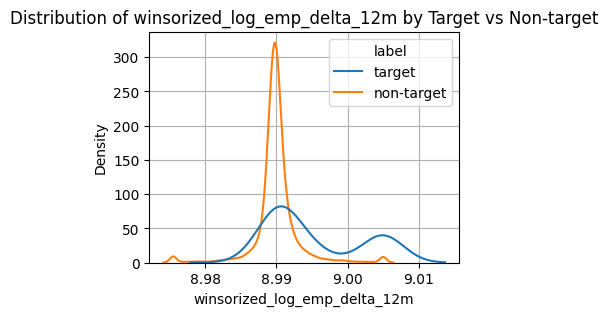

In [86]:
plot_kde(employee_features_combined, 'winsorized_log_emp_delta_12m')

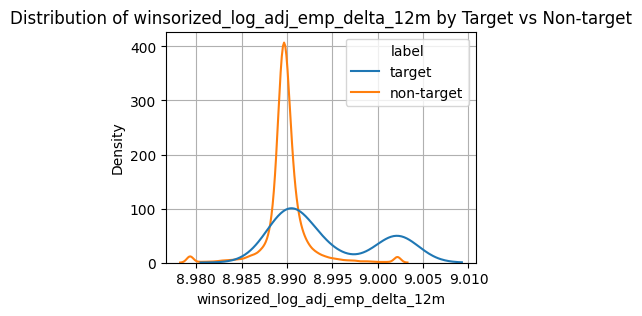

In [87]:
plot_kde(employee_features_combined, 'winsorized_log_adj_emp_delta_12m')

Given that the adjusted and raw delta features have highly similar distributions between the target and non-target groups, and that adjusted deltas normalize for confounding factors such as company size or funding, the adjusted versions (adj_emp_delta_6m, adj_emp_delta_12m) were retained for modeling to improve generalization.

In [92]:
target_employee_features.drop(columns=['emp_delta_6m', 'emp_delta_12m', 'label'], inplace=True)
employee_features.drop(columns=['emp_delta_6m', 'emp_delta_12m', 'label'], inplace=True)

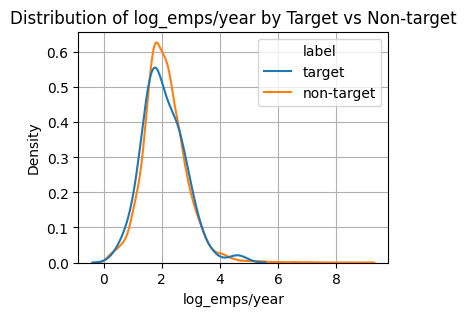

In [71]:
employee_features_combined['log_emps/year'] = np.log1p(employee_features_combined['emps/year']) # emps/year has large right skewness
plot_kde(employee_features_combined, 'log_emps/year')

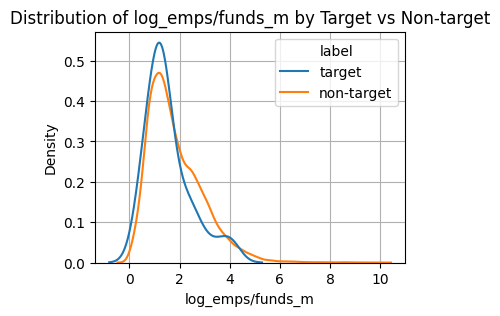

In [72]:
employee_features_combined['log_emps/funds_m'] = np.log1p(employee_features_combined['emps/funds_m']) # emps/funds_m has large right skewness
plot_kde(employee_features_combined, 'log_emps/funds_m')

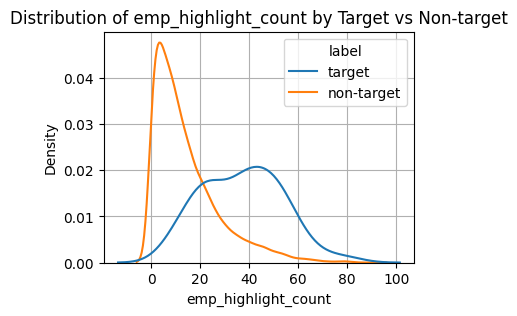

In [73]:
plot_kde(employee_features_combined, 'emp_highlight_count')

Out of the remaining three non-delta employee features, only emp_highlight_count shows a clear difference in distribution between the target and non-target groups, suggesting it is more likely to have stronger predictive power.

In [93]:
print("Final Target Employee Features:", target_employee_features.columns.tolist())
print("Final Non-Target Employee Features:", employee_features.columns.tolist())

Final Target Employee Features: ['emps/year', 'emps/funds_m', 'adj_emp_delta_6m', 'adj_emp_delta_12m', 'emp_highlight_count']
Final Non-Target Employee Features: ['emps/year', 'emps/funds_m', 'adj_emp_delta_6m', 'adj_emp_delta_12m', 'emp_highlight_count']


# Numerical data

## Understand funding features

In [53]:
target_funding_features = target_company_data.filter(like='funding').copy()
funding_features = company_data.filter(like='funding').copy()

In [54]:
target_funding_features.drop(columns=['last_funding_date'], inplace=True)
funding_features.drop(columns=['last_funding_date'], inplace=True)

In [55]:
print("Final Target Funding Features:", target_funding_features.columns.tolist())
print("Final Non-Target Funding Features:", funding_features.columns.tolist())

Final Target Funding Features: ['funding_total', 'last_funding_type', 'last_funding_total', 'funding_stage', 'revenue_funding_ratio', 'years_since_funding', 'hc_adds_since_funding']
Final Non-Target Funding Features: ['funding_total', 'last_funding_type', 'last_funding_total', 'funding_stage', 'revenue_funding_ratio', 'years_since_funding', 'hc_adds_since_funding']


## Understand founding features

In [56]:
target_founding_features = target_company_data.filter(like='founding').copy()
founding_features = company_data.filter(like='founding').copy()

Since most of the metrics are in months and a few are in years, creating a months_since_founding would be better

In [57]:
target_founding_features['months_since_founding'] = target_founding_features['days_since_founding'] // 30
founding_features['months_since_founding'] = founding_features['days_since_founding'] // 30

In [58]:
target_founding_features.drop(columns=['founding_date', 'days_since_founding'], inplace=True)
founding_features.drop(columns=['founding_date','days_since_founding'], inplace=True)

In [59]:
print("Final Target Founding Features:", target_founding_features.columns.tolist())
print("Final Non-Target Founding Features:", founding_features.columns.tolist())

Final Target Founding Features: ['years_since_founding', 'months_since_founding']
Final Non-Target Founding Features: ['years_since_founding', 'months_since_founding']


# Categorical data

helper method

In [60]:
def plot_categorical_comparison(target_df, nontarget_df, feature, normalize=True):
    """
    Plot the distribution of a categorical feature between target and non-target datasets.
    
    Args:
        target_df (pd.DataFrame): Target dataset.
        nontarget_df (pd.DataFrame): Non-target dataset.
        feature (str): Name of the categorical feature to compare.
        normalize (bool): Whether to plot percentages instead of raw counts.
    """
    # Calculate value counts
    target_counts = target_df[feature].value_counts(normalize=normalize)
    nontarget_counts = nontarget_df[feature].value_counts(normalize=normalize)
    
    # Combine into a single DataFrame
    comparison_df = pd.DataFrame({
        'Target': target_counts,
        'Non-Target': nontarget_counts
    }).fillna(0)  # Fill missing categories with 0

    # Plot
    comparison_df.plot(kind='bar', figsize=(5,5))
    plt.title(f'Comparison of {feature} between Target and Non-Target')
    plt.xlabel(feature)
    plt.ylabel('Percentage' if normalize else 'Count')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()


## Understand ownership feature

In [61]:
target_ownership = target_company_data.filter(like='ownership').copy()
ownership = company_data.filter(like='ownership').copy()

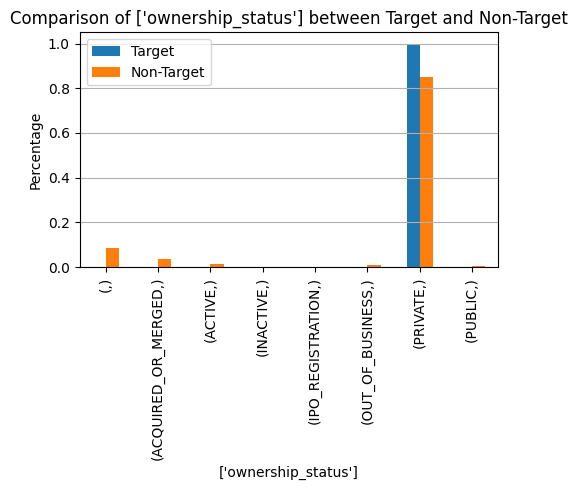

In [62]:
plot_categorical_comparison(target_ownership, ownership, ['ownership_status'])

## Understand location features

In [63]:
locations = ['united_state', 'india', 'israel', 'europe', 'canada', 'other_loc', 'United States', 'India', 'Israel',
'United Kingdom', 'Canada', 'North America', 'South America', 'Europe', 'Asia', 'Africa', 'Oceania', 'Unknown', 'Other']

target_location_features = target_company_data[locations].copy()
location_features = company_data[locations].copy()

In [64]:
target_company_data[['united_state', 'india', 'israel', 'europe', 'canada', 'other_loc', 'headcount_0m', 'headcount']]

,united_state,india,israel,europe,canada,other_loc,headcount_0m,headcount
0,30.0,0.0,0.0,1.0,0.0,0.0,101,15
1,NaN,NaN,NaN,NaN,NaN,0.0,215,18
2,18.0,1.0,0.0,8.0,0.0,0.0,49,17
3,NaN,NaN,NaN,NaN,NaN,0.0,79,11
4,NaN,NaN,NaN,NaN,NaN,0.0,102,7
...,...,...,...,...,...,...,...,...
56,16.0,0.0,0.0,0.0,0.0,0.0,38,6
57,NaN,NaN,NaN,NaN,NaN,0.0,19,19
58,13.0,0.0,0.0,2.0,0.0,0.0,20,14
59,14.0,0.0,0.0,3.0,0.0,0.0,31,13


In [65]:
company_data[['united_state', 'india', 'israel', 'europe', 'canada', 'other_loc', 'headcount_0m', 'headcount']]

,united_state,india,israel,europe,canada,other_loc,headcount_0m,headcount
0,16.0,0.0,0.0,0.0,0.0,0.0,15,15
1,9.0,0.0,0.0,1.0,0.0,3.0,13,13
4,10.0,0.0,0.0,0.0,0.0,0.0,10,10
5,NaN,NaN,NaN,NaN,NaN,0.0,12,12
6,12.0,0.0,0.0,1.0,1.0,1.0,15,15
...,...,...,...,...,...,...,...,...
15405,23.0,0.0,0.0,0.0,0.0,0.0,21,21
15436,NaN,NaN,NaN,NaN,NaN,0.0,4,4
15438,NaN,NaN,NaN,NaN,NaN,0.0,36,36
15439,NaN,NaN,NaN,NaN,NaN,0.0,11,11


In [66]:
target_company_data[['United States', 'India', 'Israel', 'United Kingdom', 'Canada', 'headcount_0m', 'headcount']]

,United States,India,Israel,United Kingdom,Canada,headcount_0m,headcount
0,46,0,0,0,0,101,15
1,20,7,0,1,0,215,18
2,14,0,0,0,0,49,17
3,12,0,0,1,0,79,11
4,11,0,0,0,0,102,7
...,...,...,...,...,...,...,...
56,15,1,0,0,0,38,6
57,2,0,0,0,0,19,19
58,6,0,0,0,0,20,14
59,14,0,0,0,1,31,13


In [67]:
company_data[['United States', 'India', 'Israel', 'United Kingdom', 'Canada', 'headcount_0m', 'headcount']]

,United States,India,Israel,United Kingdom,Canada,headcount_0m,headcount
0,3,0,0,0,0,15,15
1,2,0,0,0,0,13,13
4,5,0,0,0,0,10,10
5,5,0,0,0,2,12,12
6,2,0,0,0,0,15,15
...,...,...,...,...,...,...,...
15405,7,0,0,0,0,21,21
15436,2,0,0,0,0,4,4
15438,5,0,0,0,0,36,36
15439,2,0,0,0,0,11,11


After doing a quick look to see if the geo_sum is equivalent to either headcount_0m or headcount, there does not seem to be a relationship so it's difficult to utilize these location data when the true meaning cannot be evaluated. However we do have a sufficient amount of info on employee/headcount data so this should be okay but if our model needs supplement we can revisit this data.

'North America', 'South America', 'Europe', 'Asia', 'Africa', 'Oceania' are often market related regions(continents), so to not to overlap them with country data and excluding 'Unknown', 'Other' we will feature engineer market diversity

In [68]:
continent_cols = ['North America', 'South America', 'Europe', 'Asia', 'Africa', 'Oceania']

### multi_continent_presence

In [69]:
target_location_features['multi_continent_presence'] = (target_location_features[continent_cols].gt(0).sum(axis=1) > 1).astype(int)
location_features['multi_continent_presence'] = (location_features[continent_cols].gt(0).sum(axis=1) > 1).astype(int)

### top_region

In [70]:
target_location_features['top_region'] = target_location_features[continent_cols].idxmax(axis=1)
location_features['top_region'] = location_features[continent_cols].idxmax(axis=1)

In [71]:
target_location_features.drop(columns=locations, inplace=True)
location_features.drop(columns=locations, inplace=True)
print("Final Target Location Features:", target_location_features.columns.tolist())
print("Final Non-Target Location Features:", location_features.columns.tolist())

Final Target Location Features: ['multi_continent_presence', 'top_region']
Final Non-Target Location Features: ['multi_continent_presence', 'top_region']


## Understand business function features 

In [72]:
business_functions = ['sales', 'business_development', 'customer_success', 'health', 'community_and_social', 'education']
target_business_function_features = target_company_data[business_functions].copy()
business_function_features = company_data[business_functions].copy()

### dominant_business_function

In [73]:
target_business_function_features['dominant_function'] = target_business_function_features[business_functions].idxmax(axis=1)
business_function_features['dominant_function'] = business_function_features[business_functions].idxmax(axis=1)

### business_function_entropy
- low entropy startups might be earlier stage (e.g., all engineers, no sales yet)
- high entropy companies may be closer to go-to-market phase (balanced tech + sales + ops)
- investors might see diversity as a sign of organizational maturity

In [74]:
from scipy.stats import entropy

def calc_entropy(row, cols):
    values = row[cols].astype(float).fillna(0).values 
    total = values.sum()
    if total == 0:
        return 0
    probs = values / total
    return entropy(probs)

target_business_function_features['business_function_entropy'] = target_business_function_features.apply(calc_entropy, cols=business_functions, axis=1)
business_function_features['business_function_entropy'] = business_function_features.apply(calc_entropy, cols=business_functions, axis=1)

In [75]:
target_business_function_features.drop(columns=business_functions, inplace=True)
business_function_features.drop(columns=business_functions, inplace=True)
print("Final Target Business Function Features:", target_business_function_features.columns.tolist())
print("Final Non-Target Business Function Features:", business_function_features.columns.tolist())

Final Target Business Function Features: ['dominant_function', 'business_function_entropy']
Final Non-Target Business Function Features: ['dominant_function', 'business_function_entropy']


## Understand employee role features

In [76]:
emp_roles = ['Sales', 'Engineering', 'Marketing', 'Operations', 'Data', 'Advisor', 'Design', 'Customer Success']
target_emp_role_features = target_company_data[emp_roles].copy()
emp_role_features = company_data[emp_roles].copy()

### dominant_emp_role

In [77]:
target_emp_role_features['dominant_emp_role'] = target_emp_role_features[emp_roles].idxmax(axis=1)
emp_role_features['dominant_emp_role'] = emp_role_features[emp_roles].idxmax(axis=1)

### emp_role_entropy
- measures how role-diverse the employees are
- low entropy may hint at a technical founder-heavy company
- high entropy shows organizational depth 

In [78]:
target_emp_role_features['emp_role_entropy'] = target_emp_role_features.apply(calc_entropy, cols=emp_roles, axis=1)
emp_role_features['emp_role_entropy'] = emp_role_features.apply(calc_entropy, cols=emp_roles, axis=1)

In [79]:
target_emp_role_features.drop(columns=emp_roles, inplace=True)
emp_role_features.drop(columns=emp_roles, inplace=True)
print("Final Target Employee Role Features:", target_emp_role_features.columns.tolist())
print("Final Non-Target Employee Role Features:", emp_role_features.columns.tolist())

Final Target Employee Role Features: ['dominant_emp_role', 'emp_role_entropy']
Final Non-Target Employee Role Features: ['dominant_emp_role', 'emp_role_entropy']


## Parse List[Dict] features

In [86]:
def is_list_or_array(series):
    return series.dropna().apply(lambda x: isinstance(x, (list, np.ndarray))).any()

In [87]:
list_dict_cols_target = [col for col in target_company_data.columns if is_list_or_array(target_company_data[col])]
print("Columns with list or array values in target_company_data:", list_dict_cols_target)

list_dict_cols = [col for col in company_data.columns if is_list_or_array(company_data[col])]
print("Columns with list or array values in company_data:", list_dict_cols)

Columns with list or array values in target_company_data: ['highlights', 'employee_highlights', 'investors']
Columns with list or array values in company_data: ['highlights', 'employee_highlights', 'investors']


In [88]:
target_list_dict_features = target_company_data[list_dict_cols_target]
target_list_dict_features = target_list_dict_features.copy()

list_dict_features = company_data[list_dict_cols]
list_dict_features = list_dict_features.copy()

### investors

In [89]:
target_list_dict_features['num_investors'] = target_list_dict_features['investors'].apply(lambda x: len(x) if is_list_or_array else 0)
list_dict_features['num_investors'] = list_dict_features['investors'].apply(lambda x: len(x) if is_list_or_array else 0)

In [90]:
company_data[['investor_1', 'investor_2', 'investor_3']].isna().sum()

investor_1    0
investor_2    0
investor_3    0
dtype: int64

In [91]:
num_investor_notequal_investor_1_2_3 = target_list_dict_features['num_investors'] != target_company_data[['investor_1', 'investor_2', 'investor_3']].notna().sum(axis=1)
print("Number of rows where num_investors does not match investor_1 + investor_2 + investor_3 in target data:", num_investor_notequal_investor_1_2_3.sum())

num_investor_notequal_investor_1_2_3 = list_dict_features['num_investors'] != company_data[['investor_1', 'investor_2', 'investor_3']].notna().sum(axis=1)
print("Number of rows where num_investors does not match investor_1 + investor_2 + investor_3 in non-target data:", num_investor_notequal_investor_1_2_3.sum())

Number of rows where num_investors does not match investor_1 + investor_2 + investor_3 in target data: 59
Number of rows where num_investors does not match investor_1 + investor_2 + investor_3 in non-target data: 13680


Because there is a large number of instances where num_investors does not equal to investor_1 count + investor_2 count + investor_3 count, we can't quite define what investor_1, investor_2, and investor_3 mean just yet. This can however rule out the meaning behind investor_1, investor_2, and investor_3 being tiers. Rather they seem to be rounds and there is the possibility that an investor invested in multiple rounds and new investors were introduced at different rounds. Also the inconsistency could be for messy or partial data capture.

In [92]:
# drop investors column after extracting num_investors
target_list_dict_features.drop(columns=['investors'], inplace=True)
list_dict_features.drop(columns=['investors'], inplace=True)

### employee_highlights

In [93]:
from collections import Counter

def extract_categories(df, col_name, prefix):
    category_counts = df[col_name].apply(lambda x: dict(Counter(d['category'] for d in x if 'category' in d)))
    category_counts_df = pd.json_normalize(category_counts).fillna(0).astype(int)
    # drop categories that are already accounted for in the original dataset
    category_counts_df = category_counts_df.drop(columns=['Prior VC Backed Founder', 'Deep Technical Background', 'Prior Exit', 'Elite Industry Experience'])
    category_counts_df = category_counts_df.add_prefix(prefix)
    return category_counts_df

target_category_counts_df = extract_categories(target_list_dict_features, 'employee_highlights', 'employee_highlight_')
category_counts_df = extract_categories(list_dict_features, 'employee_highlights', 'employee_highlight_')

common_categories = target_category_counts_df.columns.intersection(category_counts_df.columns).tolist()

target_category_counts_df = target_category_counts_df[common_categories].reset_index(drop=True)
category_counts_df = category_counts_df[common_categories].reset_index(drop=True)

target_list_dict_features.reset_index(drop=True, inplace=True)
list_dict_features.reset_index(drop=True, inplace=True)

target_list_dict_features = pd.concat([target_list_dict_features, target_category_counts_df], axis=1)
list_dict_features = pd.concat([list_dict_features, category_counts_df], axis=1)

In [94]:
# drop employee_highlights column after extracting counts of employee highlight categories
target_list_dict_features.drop(columns=['employee_highlights'], inplace=True)
list_dict_features.drop(columns=['employee_highlights'], inplace=True)

In [95]:
print("Final Target List/Dict Features:", target_list_dict_features.columns.tolist())
print("Final Non-Target List/Dict Features:", list_dict_features.columns.tolist())

Final Target List/Dict Features: ['highlights', 'num_investors', 'employee_highlight_Top University', 'employee_highlight_Top Company Alum', 'employee_highlight_Major Tech Company Experience', 'employee_highlight_Seasoned Operator', 'employee_highlight_$15M Club', 'employee_highlight_Legacy Tech Company Experience', 'employee_highlight_Seasoned Executive', 'employee_highlight_YC Backed Founder', 'employee_highlight_Seasoned Adviser', 'employee_highlight_Prior VC Backed Executive', 'employee_highlight_$5M Club', 'employee_highlight_$50M+ Club', 'employee_highlight_Seasoned Founder', 'employee_highlight_Founder Turned Operator', 'employee_highlight_Major Research Institution Experience', 'employee_highlight_Current Student', 'employee_highlight_Top AI Experience', 'employee_highlight_Top Web3 Experience', 'employee_highlight_HBCU Alum', 'employee_highlight_$45M Club', 'employee_highlight_$25M Club', 'employee_highlight_$35M Club', 'employee_highlight_$30M Club', 'employee_highlight_$20M 

### highlights

In [96]:
target_list_dict_features['highlights'] = target_list_dict_features['highlights'].apply(lambda x: x if isinstance(x, np.ndarray) else [])
list_dict_features['highlights'] = list_dict_features['highlights'].apply(lambda x: x if isinstance(x, np.ndarray) else [])

In [97]:
from cleanco import basename
from urlextract import URLExtract

extractor = URLExtract()

def extract_vc_count(highlights):
    for item in highlights:
        if item.get('category') == 'Venture Backed' and item.get('text') is not None:
            text = item['text']
            # Remove the "Backed By" prefix
            firms = text.replace('Backed By ', '')
            
            urls = extractor.find_urls(text)
            urls = [url.strip(',') for url in urls]

            firms = firms.split(', ')
            firms = [firm for firm in firms if basename(firm).strip() != '' and firm not in urls]

            # Return number of unique firms
            return len(set(firms))
    return 0  # No Venture Backed category found

In [98]:
target_list_dict_features['num_unique_vc_backers'] = target_list_dict_features['highlights'].apply(extract_vc_count)
list_dict_features['num_unique_vc_backers'] = list_dict_features['highlights'].apply(extract_vc_count)

In [99]:
# drop highlights column after extracting number of venture capital firms backing the company
target_list_dict_features.drop(columns=['highlights'], inplace=True)
list_dict_features.drop(columns=['highlights'], inplace=True)

In [100]:
print("Final Target List[Dict] Features:", target_list_dict_features.columns.tolist())
print("Final Non-Target List[Dict] Features:", list_dict_features.columns.tolist())

Final Target List[Dict] Features: ['num_investors', 'employee_highlight_Top University', 'employee_highlight_Top Company Alum', 'employee_highlight_Major Tech Company Experience', 'employee_highlight_Seasoned Operator', 'employee_highlight_$15M Club', 'employee_highlight_Legacy Tech Company Experience', 'employee_highlight_Seasoned Executive', 'employee_highlight_YC Backed Founder', 'employee_highlight_Seasoned Adviser', 'employee_highlight_Prior VC Backed Executive', 'employee_highlight_$5M Club', 'employee_highlight_$50M+ Club', 'employee_highlight_Seasoned Founder', 'employee_highlight_Founder Turned Operator', 'employee_highlight_Major Research Institution Experience', 'employee_highlight_Current Student', 'employee_highlight_Top AI Experience', 'employee_highlight_Top Web3 Experience', 'employee_highlight_HBCU Alum', 'employee_highlight_$45M Club', 'employee_highlight_$25M Club', 'employee_highlight_$35M Club', 'employee_highlight_$30M Club', 'employee_highlight_$20M Club', 'emplo

## Create final features datasets

In [157]:
org_headcount_cols = company_data.filter(like='headcount').columns.tolist()
org_linkedin_cols = company_data.filter(like='linkedin').columns.tolist()
org_twitter_cols = company_data.filter(like='twitter').columns.tolist()
org_funding_cols = company_data.filter(like='funding').columns.tolist()
org_founding_cols = company_data.filter(like='founding').columns.tolist()
org_ceo_cols = company_data.filter(like='ceo').columns.tolist()
list_dict_cols = ['investors', 'employee_highlights', 'highlights']
# could extract content from description, but will do that later if needed
identifier_cols = ['website', 'entity_urn', 'harmonic_url', 'name', 'domain', 'domain_only', 'hostname', 'description', 'updated_at', 'owner_id']

remove_cols = org_headcount_cols + org_linkedin_cols + org_twitter_cols + org_funding_cols + org_founding_cols + org_ceo_cols
remove_cols += locations + business_functions + emp_roles
remove_cols += list_dict_cols + identifier_cols
print("Columns to remove from data:", remove_cols)

Columns to remove from data: ['headcount', 'headcount_0m', 'headcount_1m', 'headcount_2m', 'headcount_3m', 'headcount_4m', 'headcount_5m', 'headcount_6m', 'headcount_7m', 'headcount_8m', 'headcount_9m', 'headcount_10m', 'headcount_11m', 'headcount_12m', 'headcount_13m', 'headcount_14m', 'headcount_15m', 'headcount_16m', 'headcount_17m', 'headcount_18m', 'headcount_growth_1m', 'headcount_growth_3m', 'headcount_growth_6m', 'headcount_growth_12m', 'headcount_growth_trailing_3m_0m', 'headcount_growth_trailing_3m_1m', 'headcount_growth_trailing_3m_2m', 'headcount_growth_trailing_3m_3m', 'headcount_growth_trailing_3m_4m', 'headcount_growth_trailing_3m_5m', 'headcount_growth_trailing_3m_6m', 'headcount_growth_trailing_3m_7m', 'headcount_growth_trailing_3m_8m', 'headcount_growth_trailing_3m_9m', 'headcount_growth_trailing_3m_10m', 'headcount_growth_trailing_3m_11m', 'headcount_growth_trailing_3m_12m', 'headcount_monotonicity', 'headcount_concavity', 'max_headcount', 'adjusted_headcount', 'link

In [158]:
target_company_data_ff = target_company_data.drop(columns=remove_cols).reset_index(drop=True)
company_data_ff = company_data.drop(columns=remove_cols).reset_index(drop=True)

In [ ]:
target_company_data_ff = pd.concat(
    [
        df.reset_index(drop=True)
        for df in [
            target_company_data_ff, target_headcount_features, target_linkedin_features, target_twitter_features,
            target_funding_features, target_founding_features,
            target_business_function_features, target_emp_role_features,
            target_location_features, target_list_dict_features
        ]
    ],
    axis=1
)
company_data_ff = pd.concat(
    [
        df.reset_index(drop=True) 
        for df in [
            company_data_ff, headcount_features, linkedin_features, twitter_features,
            funding_features, founding_features,
            business_function_features, emp_role_features,
            location_features, list_dict_features
        ]
    ],
    axis=1
)

In [162]:
target_company_data_ff.to_csv('./selected_features_data/target_company_data_ff.csv', index=False)
company_data_ff.to_csv('./selected_features_data/company_data_ff.csv', index=False)